In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import math
import os
import pickle
import random
from pathlib import Path
from typing import List, Tuple, Optional, Dict, Union
from concurrent.futures import ThreadPoolExecutor

from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, v_measure_score
from sklearn.neighbors import NearestNeighbors

from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)
print('Импорты загружены')

Импорты загружены


In [3]:
# загрузка датасета
df_phillips = pd.read_csv('/content/drive/MyDrive/phillips_cleaned.csv')
df_phillips = df_phillips.dropna(subset=['image_url', 'price_usd_2026', 'year', 'month']).copy()
df_phillips = df_phillips.drop_duplicates(subset=['lot_url']).reset_index(drop=True)

# восстанавливаем local_image_path
IMAGES_DIR = Path('/content/drive/MyDrive/phillips_lot_images')

def build_local_path(row) -> str:
    lot_id = str(row['lot_url']).rstrip('/').split('/')[-1]
    ext = os.path.splitext(row['image_url'])[-1]
    if not ext or len(ext) > 5:
        ext = '.jpg'
    return str(IMAGES_DIR / f'{lot_id}{ext}')

df_phillips['local_image_path'] = df_phillips.apply(build_local_path, axis=1)
df_phillips = df_phillips[df_phillips['local_image_path'].apply(os.path.exists)].copy().reset_index(drop=True)

# загрузка эмбеддингов
embeddings = np.load('/content/drive/MyDrive/phillips_embeddings_final.npy')

print(f'Датасет: {df_phillips.shape}')
print(f'Эмбеддинги: {embeddings.shape}')
print(f'Совпадают: {len(df_phillips) == embeddings.shape[0]}')

Датасет: (24572, 24)
Эмбеддинги: (24572, 768)
Совпадают: True


In [4]:
def split_train_val_test(
    df: pd.DataFrame,
    train_dolya: float = 0.65,
    val_dolya: float = 0.175,
    test_dolya: float = 0.175,
    date_col: str = 'auction_date_clean'
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, np.ndarray, np.ndarray, np.ndarray]:

    assert abs(train_dolya + val_dolya + test_dolya - 1.0) < 1e-9

    df = df.copy()
    df['date'] = pd.to_datetime(df[date_col])

    unique_months = pd.period_range(
        start=df['date'].min().to_period('M'),
        end=df['date'].max().to_period('M'),
        freq='M'
    )

    total_months = len(unique_months)
    train_months_num = int(total_months * train_dolya)
    val_months_num = int(total_months * val_dolya)

    train_months = set(unique_months[:train_months_num])
    val_months = set(unique_months[train_months_num: train_months_num + val_months_num])
    test_months = set(unique_months[train_months_num + val_months_num:])

    def assign_split(date):
        month = date.to_period('M')
        if month in train_months:
            return 'train'
        elif month in val_months:
            return 'val'
        else:
            return 'test'

    df['split'] = df['date'].apply(assign_split)

    train_mask = (df['split'] == 'train').values
    val_mask = (df['split'] == 'val').values
    test_mask = (df['split'] == 'test').values

    print(f'Всего месяцев: {total_months}')
    print(f'Train: {train_mask.sum()} лотов, с {min(train_months)} по {max(train_months)}')
    print(f'Val:   {val_mask.sum()} лотов, с {min(val_months)} по {max(val_months)}')
    print(f'Test:  {test_mask.sum()} лотов, с {min(test_months)} по {max(test_months)}')
    print(f'Сумма долей: {train_mask.mean():.3f} / {val_mask.mean():.3f} / {test_mask.mean():.3f}')

    return df, train_mask, val_mask, test_mask

df_phillips, train_mask, val_mask, test_mask = split_train_val_test(df_phillips)

Всего месяцев: 156
Train: 12726 лотов, с 2013-04 по 2021-08
Val:   5452 лотов, с 2021-09 по 2023-11
Test:  6394 лотов, с 2023-12 по 2026-03
Сумма долей: 0.518 / 0.222 / 0.260


Объяснённая дисперсия при n=224: 77.7%


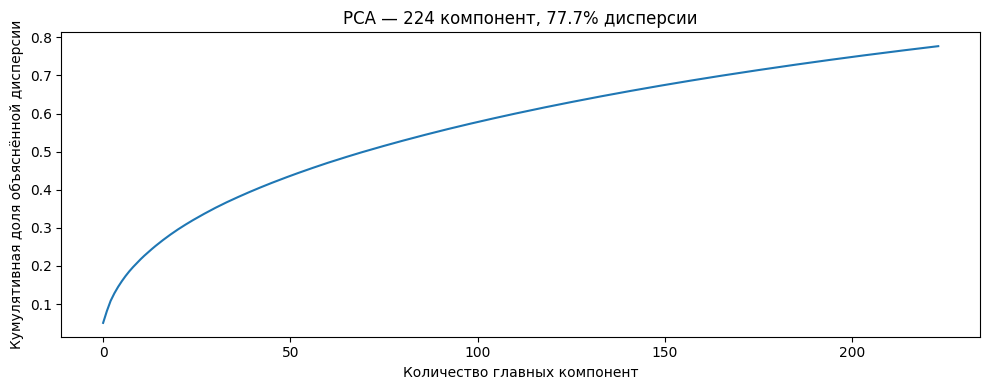

Train embeddings: (12726, 224)
Val embeddings:   (5452, 224)
Test embeddings:  (6394, 224)


In [5]:
def pca_process(
    embeddings: np.ndarray,
    n_components: int = 224,
    plot: bool = True
) -> np.ndarray:

    scaler = StandardScaler()
    embeddings_scaled = scaler.fit_transform(embeddings)

    pca = PCA(n_components=n_components, random_state=42)
    reduced_embeddings = pca.fit_transform(embeddings_scaled)

    explained = pca.explained_variance_ratio_.sum()
    print(f'Объяснённая дисперсия при n={n_components}: {explained*100:.1f}%')

    if plot:
        cumsum_var = np.cumsum(pca.explained_variance_ratio_)
        plt.figure(figsize=(10, 4))
        plt.plot(cumsum_var)
        plt.xlabel('Количество главных компонент')
        plt.ylabel('Кумулятивная доля объяснённой дисперсии')
        plt.title(f'PCA — {n_components} компонент, {explained*100:.1f}% дисперсии')
        plt.tight_layout()
        plt.show()

    return reduced_embeddings, scaler, pca

pca_embeddings, scaler, pca_model = pca_process(embeddings, n_components=224, plot=True)

# сплитуем эмбеддинги
train_embeddings = pca_embeddings[train_mask]
val_embeddings = pca_embeddings[val_mask]
test_embeddings = pca_embeddings[test_mask]

print(f'Train embeddings: {train_embeddings.shape}')
print(f'Val embeddings:   {val_embeddings.shape}')
print(f'Test embeddings:  {test_embeddings.shape}')

In [6]:
from typing import Literal

def find_best_n_cluster(
    embeddings: np.ndarray,
    k_range: range = range(10, 40),
    batch_size: int = None,
    metric: Literal['inertia', 'silhouette'] = 'silhouette',
    random_state: int = 42
) -> int:

    k_clusters = list(k_range)

    if batch_size is None:
        batch_size = int(np.sqrt(len(embeddings))) + 1

    scores = []

    for k in tqdm(k_clusters, desc='Поиск оптимального числа кластеров'):
        k_means = MiniBatchKMeans(
            n_clusters=k,
            batch_size=batch_size,
            max_iter=350,
            n_init=7,
            random_state=random_state
        )
        labels = k_means.fit_predict(embeddings)

        if metric == 'inertia':
            score = k_means.inertia_
        elif metric == 'silhouette':
            score = silhouette_score(
                embeddings,
                labels,
                sample_size=int(len(embeddings) * 0.70),
                random_state=random_state
            )
        scores.append(score)

    if metric == 'inertia':
        first_diff = np.diff(scores)
        second_diff = np.diff(first_diff)
        best_k = k_clusters[np.argmax(second_diff) + 1]
    else:
        best_k = k_clusters[np.argmax(scores)]

    print(f'Оптимальное число кластеров: {best_k}')
    return best_k


def clusterisation(
    embeddings: np.ndarray,
    n_clusters: int = None,
    k_range: range = range(10, 40),
    batch_size: int = 1024,
    random_state: int = 42,
    verbose: bool = True,
    pretrained_model=None
) -> Tuple[np.ndarray, np.ndarray, object]:

    if pretrained_model is not None:
        if verbose:
            print('Используется уже обученная модель')
        cluster_model = pretrained_model
        labels = cluster_model.predict(embeddings)
        n_clusters = cluster_model.n_clusters
    else:
        if n_clusters is None:
            n_clusters = find_best_n_cluster(
                embeddings,
                k_range=k_range,
                random_state=random_state
            )

        cluster_model = MiniBatchKMeans(
            n_clusters=n_clusters,
            random_state=random_state,
            batch_size=batch_size,
            max_iter=350,
            n_init=10
        )
        labels = cluster_model.fit_predict(embeddings)

    centers = cluster_model.cluster_centers_
    distances = np.array([
        np.linalg.norm(embeddings[i] - centers[labels[i]])
        for i in range(len(embeddings))
    ])

    if verbose:
        print(f'Количество кластеров: {n_clusters}')
        print(f'Inertia: {cluster_model.inertia_:.2f}')
        print(pd.Series(labels).value_counts().sort_index())

    return labels, distances, cluster_model

In [7]:
train_labels, train_distances, clustering_model = clusterisation(
    train_embeddings,
    n_clusters=None,
    k_range=range(10, 40)
)

with open('/content/drive/MyDrive/phillips_clustering_model.pickle', 'wb') as f:
    pickle.dump(clustering_model, f)

print('Модель сохранена')

Поиск оптимального числа кластеров:   0%|          | 0/30 [00:00<?, ?it/s]

Оптимальное число кластеров: 15
Количество кластеров: 15
Inertia: 6284832.00
0      795
1      995
2      299
3      552
4     1362
5      977
6     1406
7      971
8      285
9      610
10     866
11     871
12     575
13    1078
14    1084
Name: count, dtype: int64
Модель сохранена


In [8]:
val_labels, val_distances, _ = clusterisation(
    val_embeddings,
    pretrained_model=clustering_model
)

test_labels, test_distances, _ = clusterisation(
    test_embeddings,
    pretrained_model=clustering_model
)

print(f'Val labels: {val_labels.shape}, уникальных кластеров: {len(set(val_labels))}')
print(f'Test labels: {test_labels.shape}, уникальных кластеров: {len(set(test_labels))}')

Используется уже обученная модель
Количество кластеров: 15
Inertia: 6284832.00
0      363
1      482
2      156
3      176
4      570
5      314
6      730
7      204
8       98
9      151
10     220
11     262
12     157
13     483
14    1086
Name: count, dtype: int64
Используется уже обученная модель
Количество кластеров: 15
Inertia: 6284832.00
0      321
1      546
2      134
3      196
4      693
5      417
6      747
7      229
8      142
9      127
10     365
11     345
12     195
13     583
14    1354
Name: count, dtype: int64
Val labels: (5452,), уникальных кластеров: 15
Test labels: (6394,), уникальных кластеров: 15


Elbow method:   0%|          | 0/38 [00:00<?, ?it/s]

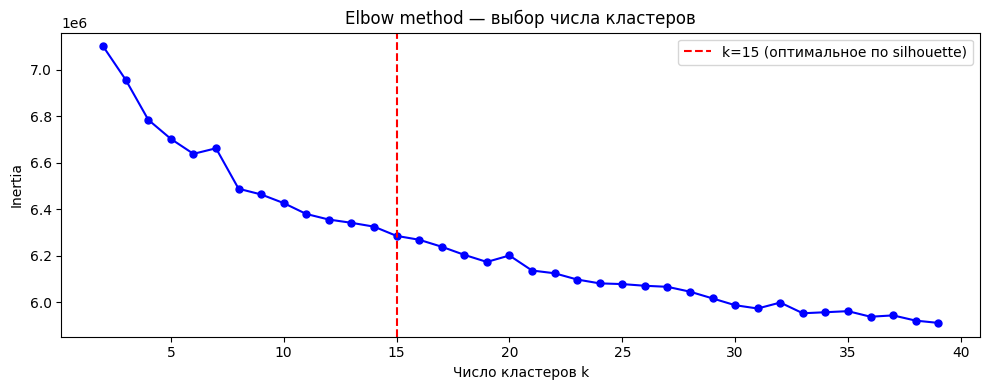

In [9]:
def elbow_method(
    embeddings: np.ndarray,
    k_range: range = range(2, 40),
    best_k: int = None,
    random_state: int = 42
) -> None:

    inertias = []
    k_values = list(k_range)

    for k in tqdm(k_values, desc='Elbow method'):
        kmeans = MiniBatchKMeans(
            n_clusters=k,
            random_state=random_state,
            batch_size=1024,
            n_init=10,
            max_iter=350
        )
        kmeans.fit(embeddings)
        inertias.append(kmeans.inertia_)

    plt.figure(figsize=(10, 4))
    plt.plot(k_values, inertias, 'bo-', markersize=5)
    if best_k is not None:
        plt.axvline(x=best_k, color='r', linestyle='--',
                    label=f'k={best_k} (оптимальное по silhouette)')
    plt.xlabel('Число кластеров k')
    plt.ylabel('Inertia')
    plt.title('Elbow method — выбор числа кластеров')
    plt.legend()
    plt.tight_layout()
    plt.show()

elbow_method(train_embeddings, k_range=range(2, 40), best_k=15)

Silhouette score (сэмпл 5000): 0.0059

Bootstrap устойчивость (10 итераций, 80% данных):


Bootstrap:   0%|          | 0/10 [00:00<?, ?it/s]

Среднее silhouette: 0.0072
Стд. отклонение:    0.0043
Мин / Макс:         0.0005 / 0.0157


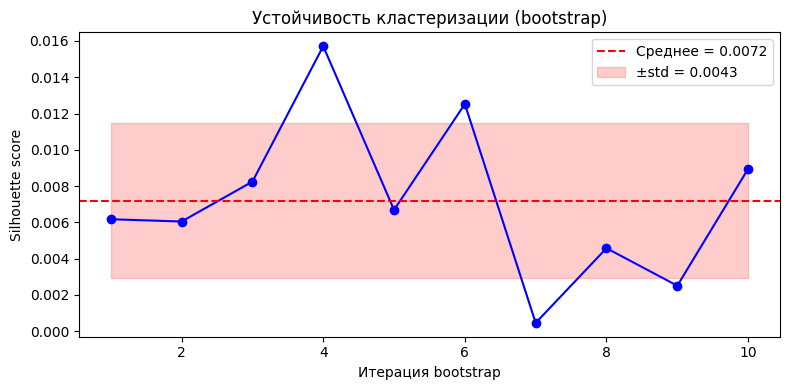

In [10]:
def evaluate_clustering(
    embeddings: np.ndarray,
    labels: np.ndarray,
    n_bootstrap: int = 10,
    sample_frac: float = 0.8,
    random_state: int = 42
) -> None:

    np.random.seed(random_state)

    # silhouette на полном train (сэмпл для скорости)
    sample_size = min(5000, len(embeddings))
    sample_idx = np.random.choice(len(embeddings), sample_size, replace=False)
    full_silhouette = silhouette_score(
        embeddings[sample_idx],
        labels[sample_idx],
        metric='euclidean'
    )
    print(f'Silhouette score (сэмпл {sample_size}): {full_silhouette:.4f}')

    # bootstrap
    print(f'\nBootstrap устойчивость ({n_bootstrap} итераций, {sample_frac*100:.0f}% данных):')
    bootstrap_scores = []

    for i in tqdm(range(n_bootstrap), desc='Bootstrap'):
        n_sample = int(len(embeddings) * sample_frac)
        idx = np.random.choice(len(embeddings), n_sample, replace=False)
        emb_sample = embeddings[idx]

        kmeans = MiniBatchKMeans(
            n_clusters=clustering_model.n_clusters,
            random_state=np.random.randint(0, 10000),
            batch_size=1024,
            n_init=7,
            max_iter=350
        )
        labels_sample = kmeans.fit_predict(emb_sample)
        score = silhouette_score(emb_sample, labels_sample, metric='euclidean')
        bootstrap_scores.append(score)

    bootstrap_scores = np.array(bootstrap_scores)
    print(f'Среднее silhouette: {bootstrap_scores.mean():.4f}')
    print(f'Стд. отклонение:    {bootstrap_scores.std():.4f}')
    print(f'Мин / Макс:         {bootstrap_scores.min():.4f} / {bootstrap_scores.max():.4f}')

    plt.figure(figsize=(8, 4))
    plt.plot(range(1, n_bootstrap + 1), bootstrap_scores, 'bo-', markersize=6)
    plt.axhline(y=bootstrap_scores.mean(), color='r', linestyle='--',
                label=f'Среднее = {bootstrap_scores.mean():.4f}')
    plt.fill_between(
        range(1, n_bootstrap + 1),
        bootstrap_scores.mean() - bootstrap_scores.std(),
        bootstrap_scores.mean() + bootstrap_scores.std(),
        alpha=0.2, color='r', label=f'±std = {bootstrap_scores.std():.4f}'
    )
    plt.xlabel('Итерация bootstrap')
    plt.ylabel('Silhouette score')
    plt.title('Устойчивость кластеризации (bootstrap)')
    plt.legend()
    plt.tight_layout()
    plt.show()

evaluate_clustering(train_embeddings, train_labels, n_bootstrap=10, sample_frac=0.8)

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
artist_labels = le.fit_transform(df_phillips.loc[train_mask, 'artist'].fillna('Unknown'))

ari = adjusted_rand_score(artist_labels, train_labels)
v_measure = v_measure_score(artist_labels, train_labels)

print(f'Adjusted Rand Index (ARI):  {ari:.4f}')
print(f'V-measure:                  {v_measure:.4f}')
print()
print('Интерпретация:')
print(f'ARI = {ari:.4f} — {"слабое" if abs(ari) < 0.1 else "умеренное" if abs(ari) < 0.3 else "сильное"} '
      f'совпадение кластеров с авторством')
print(f'V-measure = {v_measure:.4f} — {"слабое" if v_measure < 0.1 else "умеренное" if v_measure < 0.3 else "сильное"} '
      f'соответствие между кластерами и авторами')

Adjusted Rand Index (ARI):  0.0111
V-measure:                  0.3211

Интерпретация:
ARI = 0.0111 — слабое совпадение кластеров с авторством
V-measure = 0.3211 — сильное соответствие между кластерами и авторами


In [12]:
df_train_view = df_phillips[train_mask].copy().reset_index(drop=True)
df_train_view['cluster'] = train_labels

# топ-3 автора в каждом кластере
cluster_artist = df_train_view.groupby(['cluster', 'artist']).size().reset_index(name='count')
cluster_artist = cluster_artist.sort_values(['cluster', 'count'], ascending=[True, False])

print('Топ-3 автора в каждом кластере:\n')
for cluster_id in sorted(df_train_view['cluster'].unique()):
    cluster_size = (train_labels == cluster_id).sum()
    top3 = cluster_artist[cluster_artist['cluster'] == cluster_id].head(3)
    artists_str = ', '.join([
        f"{row['artist']} ({row['count']})"
        for _, row in top3.iterrows()
    ])
    print(f'Кластер {cluster_id:2d} (n={cluster_size:4d}): {artists_str}')

Топ-3 автора в каждом кластере:

Кластер  0 (n= 795): David Ostrowski (27), Wolfgang Tillmans (16), Thomas Ruff (13)
Кластер  1 (n= 995): George Condo (47), Jean-Michel Basquiat (28), Andy Warhol (26)
Кластер  2 (n= 299): KAWS (143), Takashi Murakami (31), Yoshitomo Nara (22)
Кластер  3 (n= 552): Jeff Koons (21), Henry Moore (19), Ugo Rondinone (13)
Кластер  4 (n=1362): Gerhard Richter (65), Stanley Casselman (27), Dan Rees (21)
Кластер  5 (n= 977): Andy Warhol (87), Banksy (32), Cindy Sherman (28)
Кластер  6 (n=1406): KAWS (28), Tracey Emin (27), Andy Warhol (24)
Кластер  7 (n= 971): Ethan Cook (25), Parker Ito (18), Callum Innes (17)
Кластер  8 (n= 285): Sterling Ruby (11), John Chamberlain (10), Grayson Perry (9)
Кластер  9 (n= 610): Anish Kapoor (14), John Chamberlain (12), Anselm Reyle (9)
Кластер 10 (n= 866): Andy Warhol (15), Ed Ruscha (14), Wolfgang Tillmans (14)
Кластер 11 (n= 871): Damien Hirst (23), Lucien Smith (19), Bernard Aubertin (11)
Кластер 12 (n= 575): Franz West (38

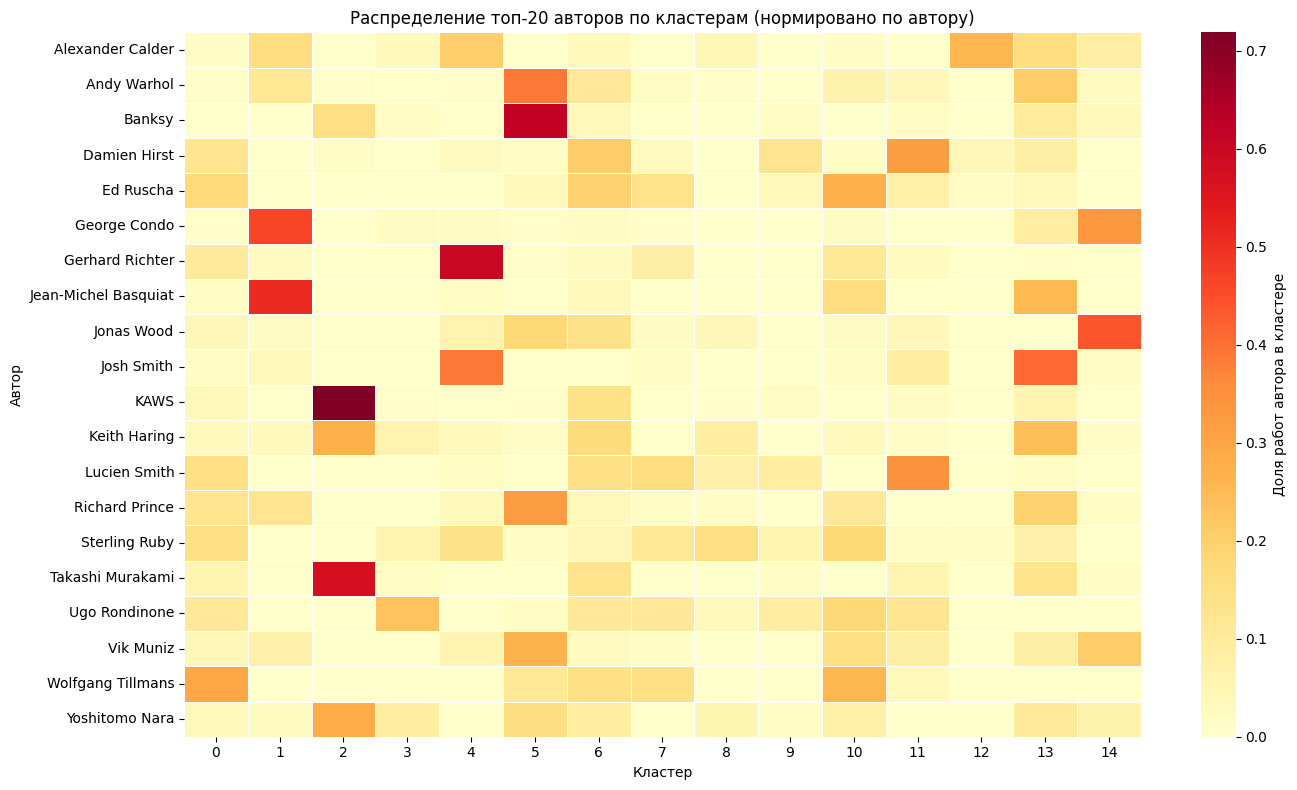

In [13]:
top_artists = df_train_view['artist'].value_counts().head(20).index.tolist()
df_top = df_train_view[df_train_view['artist'].isin(top_artists)].copy()

heatmap_data = df_top.groupby(['artist', 'cluster']).size().unstack(fill_value=0)
heatmap_norm = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)

plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_norm,
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Доля работ автора в кластере'}
)
plt.title('Распределение топ-20 авторов по кластерам (нормировано по автору)')
plt.xlabel('Кластер')
plt.ylabel('Автор')
plt.tight_layout()
plt.show()

In [14]:
def get_visual_features(image_path: str) -> Optional[Dict]:
    try:
        with Image.open(image_path) as image:
            image = image.convert('RGB')
            image.thumbnail((256, 256), Image.Resampling.LANCZOS)
            w, h = image.size
            img_np = np.asarray(image, dtype=np.float32)

            R, G, B = img_np[:, :, 0], img_np[:, :, 1], img_np[:, :, 2]

            rg = np.abs(R - G)
            yb = np.abs(0.5 * (R + G) - B)
            std_root = np.sqrt(np.std(rg) ** 2 + np.std(yb) ** 2)
            mean_root = np.sqrt(np.mean(rg) ** 2 + np.mean(yb) ** 2)
            colorfulness = std_root + 0.3 * mean_root

            hsv_np = np.array(image.convert('HSV'), dtype=np.float32)
            h_channel = hsv_np[:, :, 0] * 2
            s = hsv_np[:, :, 1] / 255.0
            v = hsv_np[:, :, 2] / 255.0

            saturation = float(np.mean(s))
            bright = float(np.mean(v))
            hue_std = float(np.std(hsv_np[:, :, 0] / 255.0))

            short_mask = (h_channel >= 210) & (h_channel < 330)
            mid_mask   = (h_channel >= 90)  & (h_channel < 210)
            long_mask  = (h_channel < 90)   | (h_channel >= 330)
            total_pixels = h_channel.size

            short_wave_ratio = float(np.sum(short_mask) / total_pixels)
            mid_wave_ratio   = float(np.sum(mid_mask)   / total_pixels)
            long_wave_ratio  = float(np.sum(long_mask)  / total_pixels)

            gray_image = image.convert('L')
            gray_np = np.array(gray_image, dtype=np.float32)
            contrast = float(np.std(gray_np) / 255.0)

            hist = np.array(gray_image.histogram(), dtype=np.float32)
            prob = hist / hist.sum()
            entropy = float(-np.sum(prob[prob > 0] * np.log2(prob[prob > 0])))

            warmth = float((np.mean(R) - np.mean(B)) / 255.0)

            return {
                'aspect_ratio':     round(w / h, 3),
                'colorfulness':     round(float(colorfulness), 3),
                'saturation':       round(saturation, 3),
                'bright':           round(bright, 3),
                'contrast':         round(contrast, 3),
                'entropy':          round(entropy, 3),
                'warmth':           round(warmth, 3),
                'hue_std':          round(hue_std, 3),
                'short_wave_ratio': round(short_wave_ratio, 3),
                'mid_wave_ratio':   round(mid_wave_ratio, 3),
                'long_wave_ratio':  round(long_wave_ratio, 3),
            }

    except Exception as e:
        print(f'Ошибка для {image_path}: {e}')
        return None

# тест
test_feat = get_visual_features(df_phillips.iloc[0]['local_image_path'])
print(test_feat)

{'aspect_ratio': 0.75, 'colorfulness': 30.292, 'saturation': 0.228, 'bright': 0.61, 'contrast': 0.133, 'entropy': 6.479, 'warmth': 0.139, 'hue_std': 0.292, 'short_wave_ratio': 0.063, 'mid_wave_ratio': 0.0, 'long_wave_ratio': 0.937}


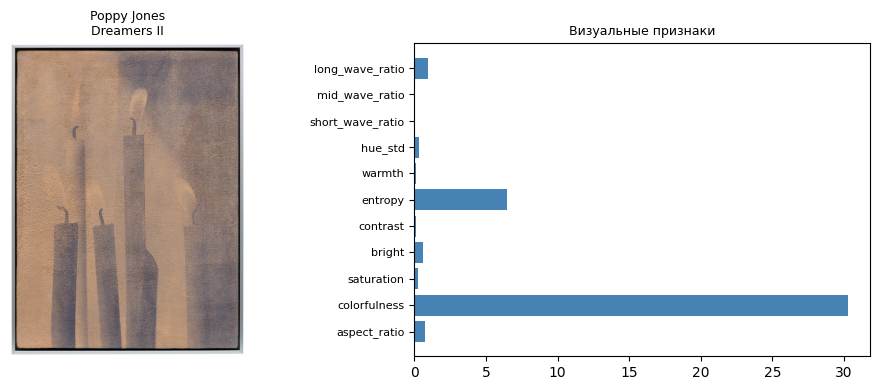

In [15]:
img = Image.open(df_phillips.iloc[0]['local_image_path']).convert('RGB')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(img)
axes[0].set_title(f'{df_phillips.iloc[0]["artist"]}\n{df_phillips.iloc[0]["title"]}', fontsize=9)
axes[0].axis('off')

features = get_visual_features(df_phillips.iloc[0]['local_image_path'])
axes[1].barh(list(features.keys()), list(features.values()), color='steelblue')
axes[1].set_title('Визуальные признаки', fontsize=9)
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

In [16]:
image_paths = df_phillips['local_image_path'].tolist()

with ThreadPoolExecutor(max_workers=8) as executor:
    visual_features_list = list(tqdm(
        executor.map(get_visual_features, image_paths),
        total=len(image_paths),
        desc='Визуальные признаки'
    ))

failed = sum(1 for x in visual_features_list if x is None)
print(f'Готово. Ошибок: {failed}')

Визуальные признаки:   0%|          | 0/24572 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
df_visual = pd.DataFrame(visual_features_list)
df_visual['local_image_path'] = image_paths

df_visual.to_csv('/content/drive/MyDrive/phillips_visual_features.csv', index=False)
print(f'Сохранено: phillips_visual_features.csv, размерность: {df_visual.shape}')

Сохранено: phillips_visual_features.csv, размерность: (24572, 12)


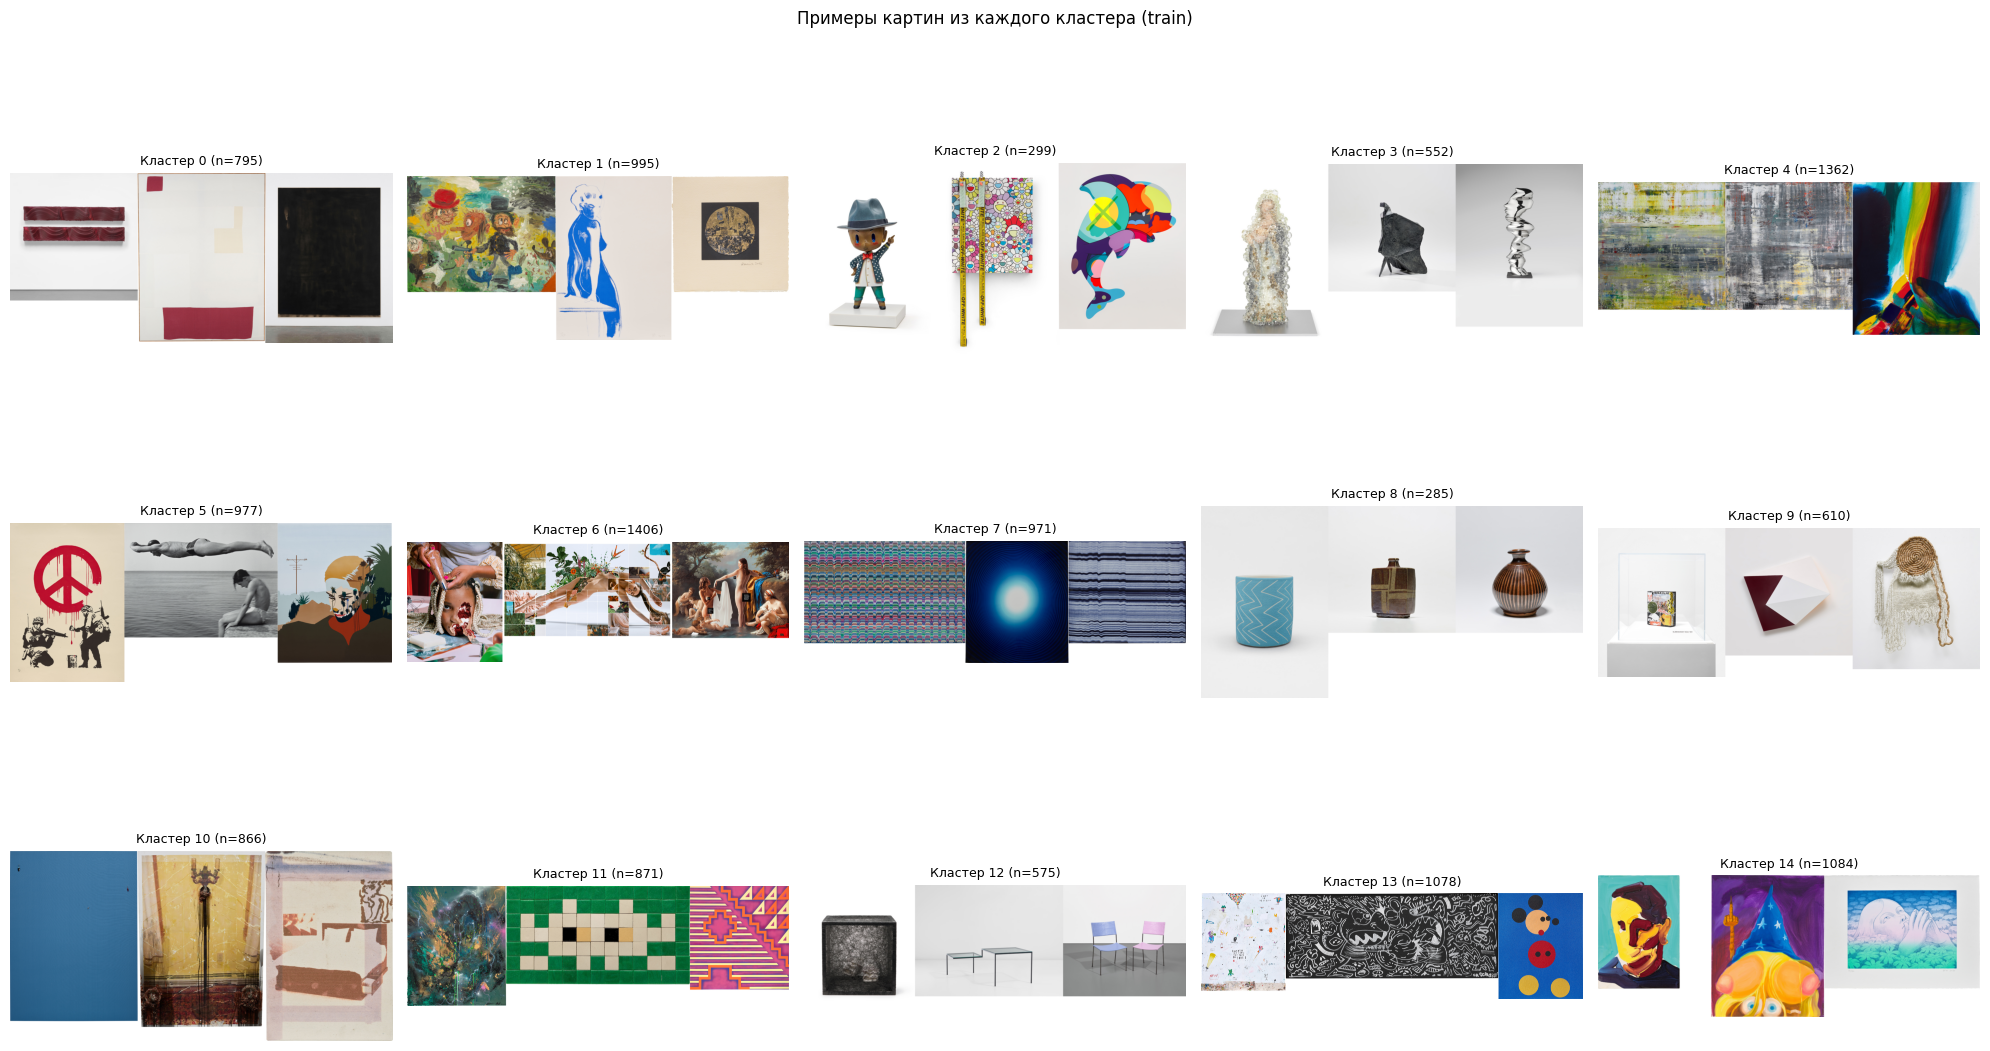

In [17]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

df_train_view = df_phillips[train_mask].copy().reset_index(drop=True)
df_train_view['cluster'] = train_labels

for cluster_id in range(15):
    cluster_idx = np.where(train_labels == cluster_id)[0]
    sample_idx = cluster_idx[:3]

    images = []
    for idx in sample_idx:
        img = Image.open(df_train_view.iloc[idx]['local_image_path']).convert('RGB')
        images.append(img)

    # склеиваем 3 картинки в одну
    widths = [img.width for img in images]
    heights = [img.height for img in images]
    max_h = max(heights)
    total_w = sum(widths)

    combined = Image.new('RGB', (total_w, max_h), (255, 255, 255))
    x_offset = 0
    for img in images:
        combined.paste(img, (x_offset, 0))
        x_offset += img.width

    axes[cluster_id].imshow(combined)
    axes[cluster_id].set_title(
        f'Кластер {cluster_id} (n={len(cluster_idx)})',
        fontsize=9
    )
    axes[cluster_id].axis('off')

plt.suptitle('Примеры картин из каждого кластера (train)', fontsize=12)
plt.tight_layout()
plt.show()

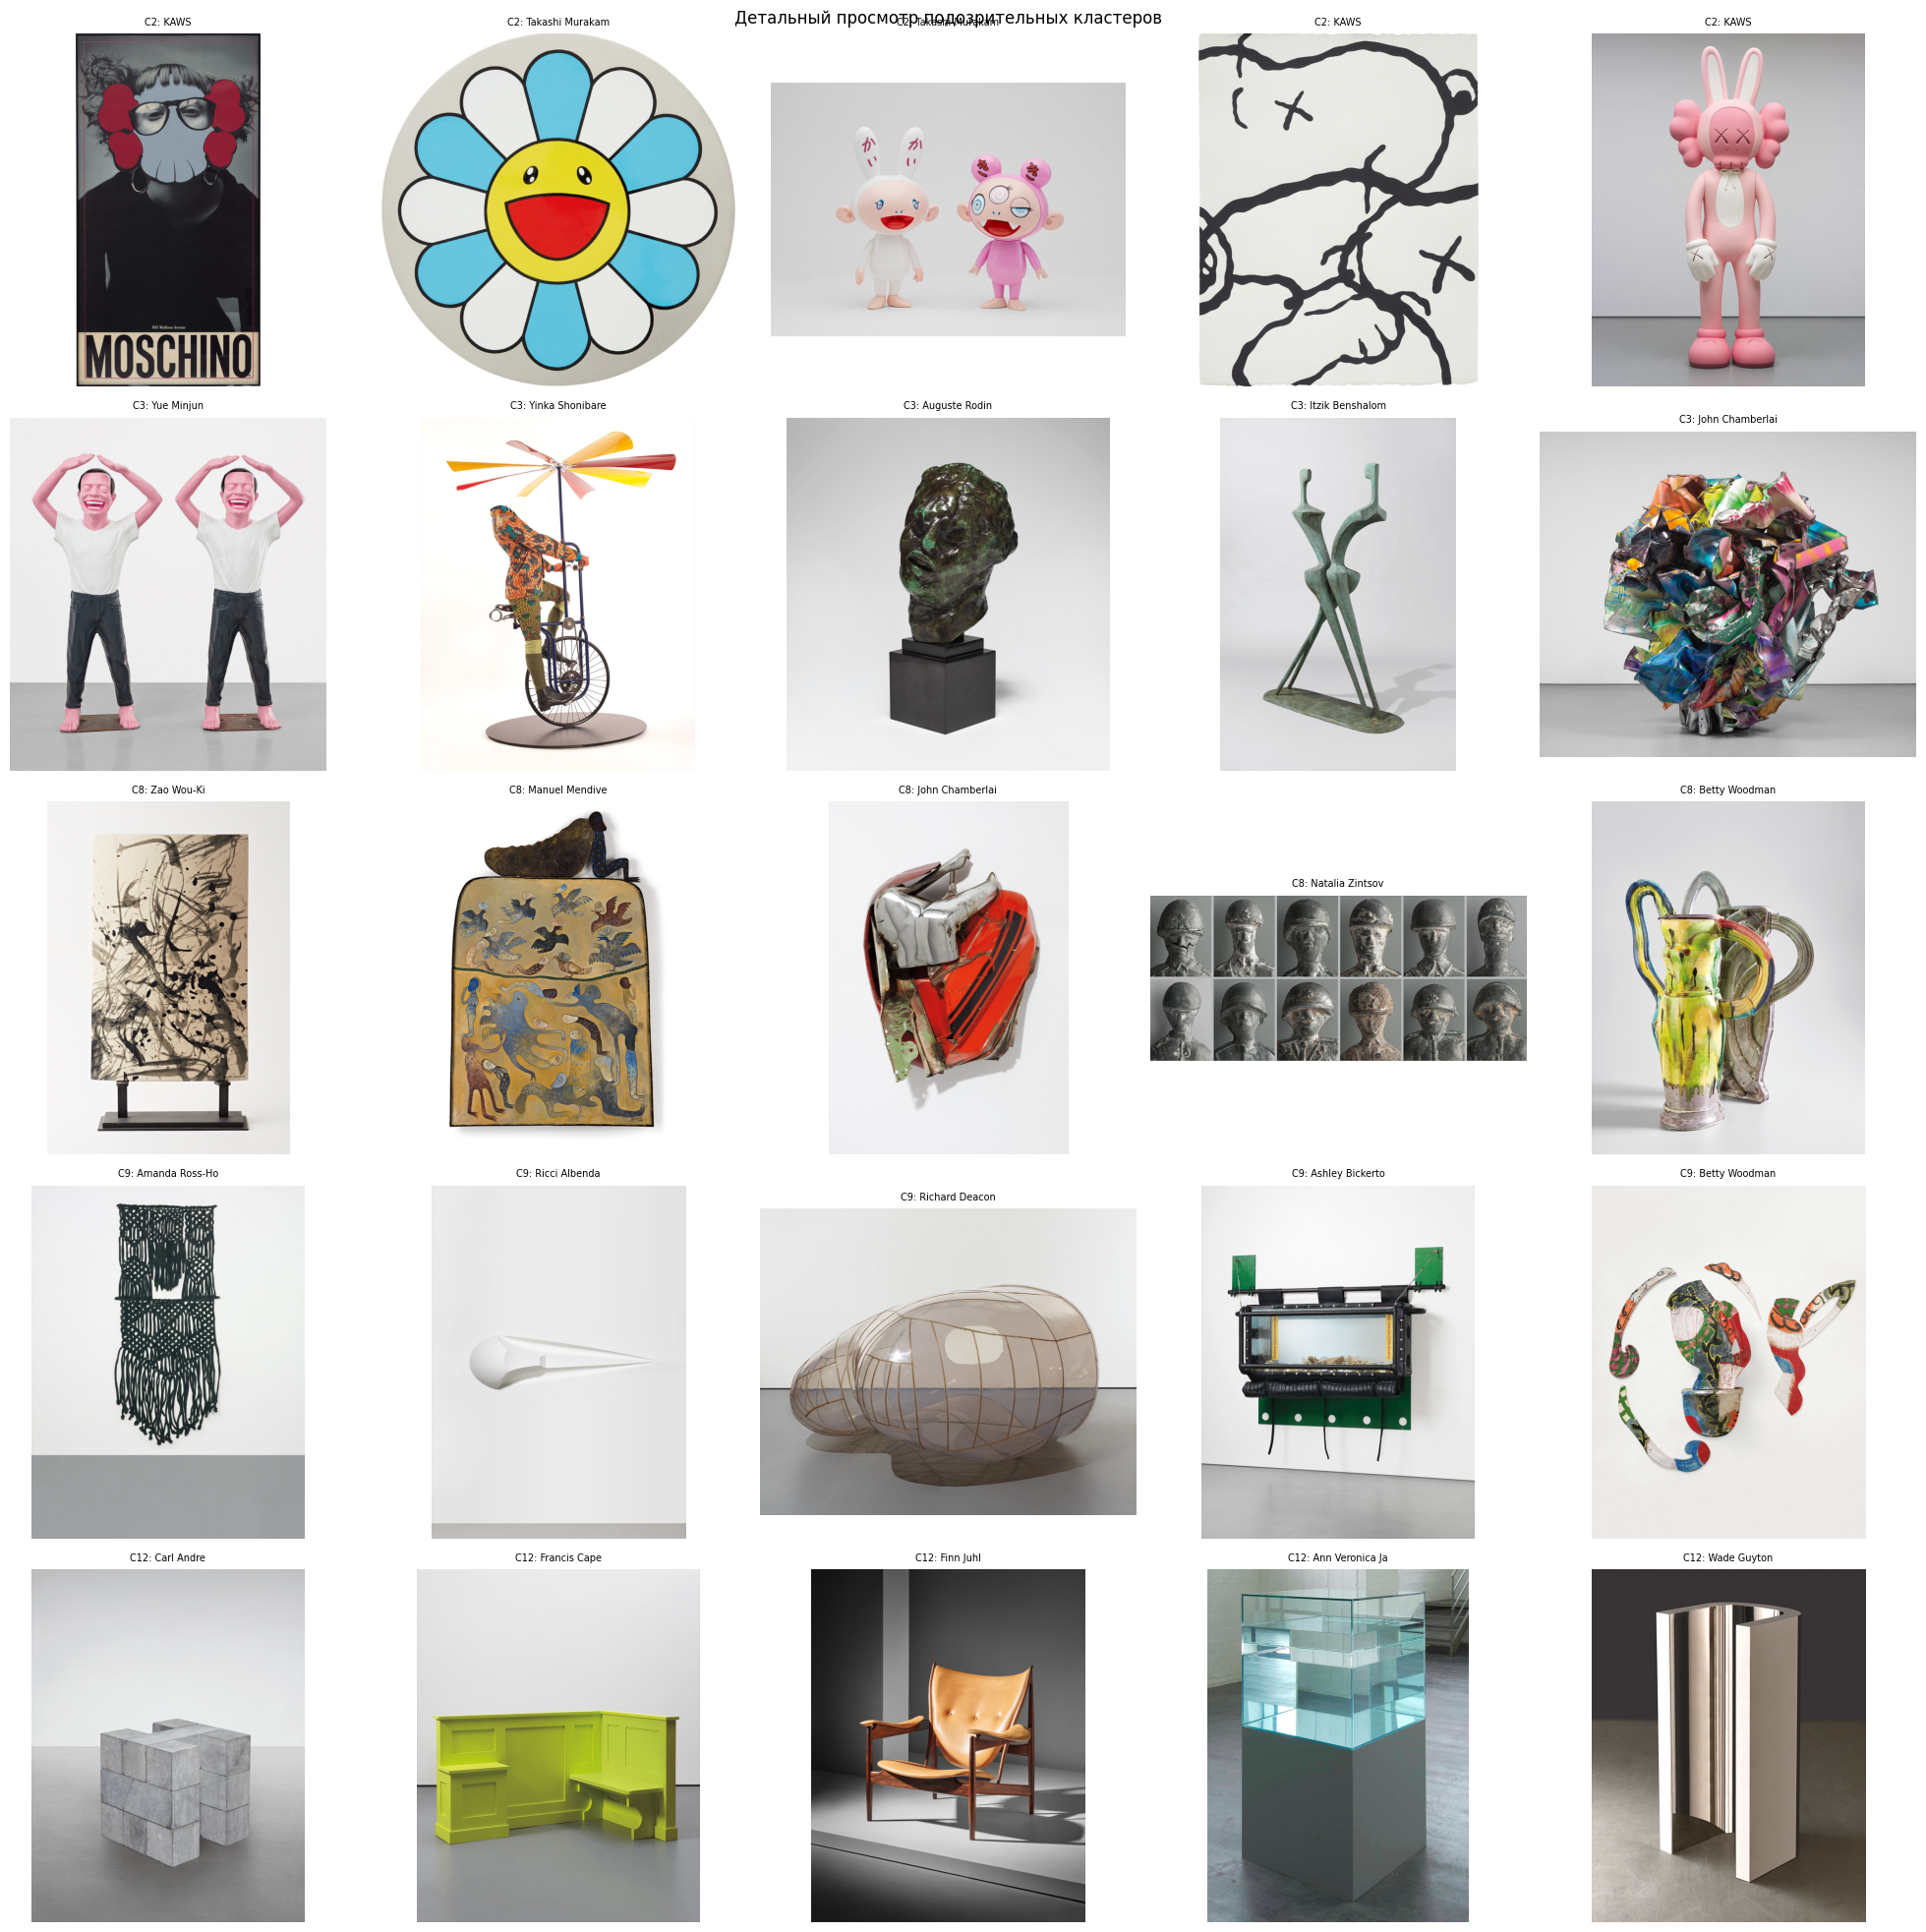

In [18]:
suspect_clusters = [2, 3, 8, 9, 12]

fig, axes = plt.subplots(len(suspect_clusters), 5, figsize=(20, 4 * len(suspect_clusters)))

for row, cluster_id in enumerate(suspect_clusters):
    cluster_idx = np.where(train_labels == cluster_id)[0]
    sample_idx = np.random.choice(cluster_idx, min(5, len(cluster_idx)), replace=False)

    for col, idx in enumerate(sample_idx):
        img = Image.open(df_train_view.iloc[idx]['local_image_path']).convert('RGB')
        axes[row, col].imshow(img)
        axes[row, col].set_title(
            f'C{cluster_id}: {df_train_view.iloc[idx]["artist"][:15]}',
            fontsize=7
        )
        axes[row, col].axis('off')

plt.suptitle('Детальный просмотр подозрительных кластеров', fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
df_visual = pd.read_csv('/content/drive/MyDrive/phillips_visual_features.csv')
print(f'df_visual загружен: {df_visual.shape}')

# определяем какие индексы удаляем (из всего датасета, не только train)
# для этого нужны метки для всего датасета

all_labels = np.empty(len(df_phillips), dtype=int)
all_labels[train_mask] = train_labels
all_labels[val_mask] = val_labels
all_labels[test_mask] = test_labels

# кластеры которые удаляем
remove_clusters = [3, 8, 9, 12]

keep_mask = ~np.isin(all_labels, remove_clusters)

df_phillips_clean = df_phillips[keep_mask].copy().reset_index(drop=True)
embeddings_clean = embeddings[keep_mask]
df_visual_clean = df_visual[keep_mask].reset_index(drop=True)

print(f'Исходный датасет: {len(df_phillips)}')
print(f'Удалено лотов: {(~keep_mask).sum()}')
print(f'Очищенный датасет: {len(df_phillips_clean)}')

df_visual загружен: (24572, 12)
Исходный датасет: 24572
Удалено лотов: 3264
Очищенный датасет: 21308


In [21]:
df_phillips_clean, train_mask_clean, val_mask_clean, test_mask_clean = split_train_val_test(df_phillips_clean)

print(f'Train: {train_mask_clean.sum()}')
print(f'Val:   {val_mask_clean.sum()}')
print(f'Test:  {test_mask_clean.sum()}')

Всего месяцев: 156
Train: 10704 лотов, с 2013-04 по 2021-08
Val:   4870 лотов, с 2021-09 по 2023-11
Test:  5734 лотов, с 2023-12 по 2026-03
Сумма долей: 0.502 / 0.229 / 0.269
Train: 10704
Val:   4870
Test:  5734


In [22]:
pca_embeddings_clean, scaler, pca_model = pca_process(embeddings_clean, n_components=224, plot=False)

train_embeddings_clean = pca_embeddings_clean[train_mask_clean]
val_embeddings_clean = pca_embeddings_clean[val_mask_clean]
test_embeddings_clean = pca_embeddings_clean[test_mask_clean]

print(f'Train: {train_embeddings_clean.shape}')
print(f'Val:   {val_embeddings_clean.shape}')
print(f'Test:  {test_embeddings_clean.shape}')

Объяснённая дисперсия при n=224: 78.0%
Train: (10704, 224)
Val:   (4870, 224)
Test:  (5734, 224)


In [23]:
train_labels_clean, train_distances_clean, clustering_model_clean = clusterisation(
    train_embeddings_clean,
    n_clusters=None,
    k_range=range(10, 40)
)

with open('/content/drive/MyDrive/phillips_clustering_model_clean.pickle', 'wb') as f:
    pickle.dump(clustering_model_clean, f)

print('Модель сохранена')

Поиск оптимального числа кластеров:   0%|          | 0/30 [00:00<?, ?it/s]

Оптимальное число кластеров: 17
Количество кластеров: 17
Inertia: 5267047.00
0     512
1     726
2     441
3     680
4     528
5     635
6     946
7     780
8     562
9     291
10    638
11    574
12    819
13    822
14    805
15    444
16    501
Name: count, dtype: int64
Модель сохранена


In [24]:
val_labels_clean, val_distances_clean, _ = clusterisation(
    val_embeddings_clean,
    pretrained_model=clustering_model_clean
)

test_labels_clean, test_distances_clean, _ = clusterisation(
    test_embeddings_clean,
    pretrained_model=clustering_model_clean
)

print(f'Val labels: {val_labels_clean.shape}, уникальных: {len(set(val_labels_clean))}')
print(f'Test labels: {test_labels_clean.shape}, уникальных: {len(set(test_labels_clean))}')

Используется уже обученная модель
Количество кластеров: 17
Inertia: 5267047.00
0     193
1     248
2     168
3     305
4     173
5     153
6     179
7     287
8     291
9     320
10    281
11    187
12    612
13    854
14    187
15    236
16    196
Name: count, dtype: int64
Используется уже обученная модель
Количество кластеров: 17
Inertia: 5267047.00
0      249
1      295
2      212
3      227
4      223
5      254
6      228
7      300
8      372
9       76
10     364
11     325
12     660
13    1037
14     314
15     334
16     264
Name: count, dtype: int64
Val labels: (4870,), уникальных: 17
Test labels: (5734,), уникальных: 17


Elbow method:   0%|          | 0/38 [00:00<?, ?it/s]

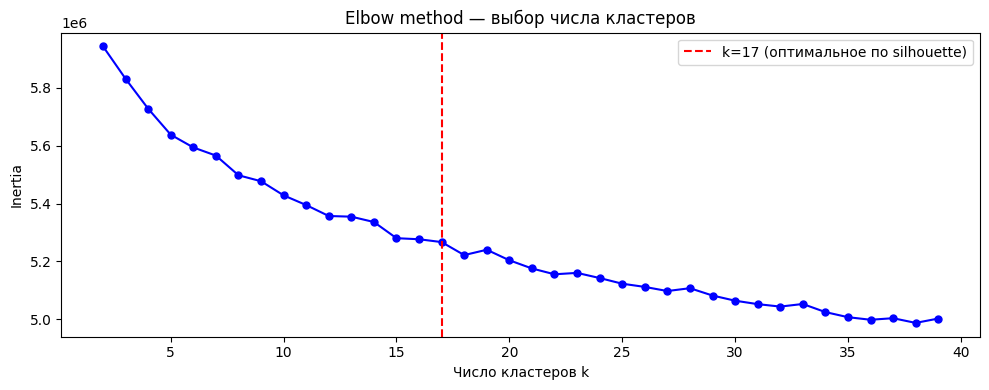

In [25]:
elbow_method(train_embeddings_clean, k_range=range(2, 40), best_k=17)

Silhouette score (сэмпл 5000): -0.0023

Bootstrap устойчивость (10 итераций, 80% данных):


Bootstrap:   0%|          | 0/10 [00:00<?, ?it/s]

Среднее silhouette: 0.0066
Стд. отклонение:    0.0031
Мин / Макс:         0.0011 / 0.0107


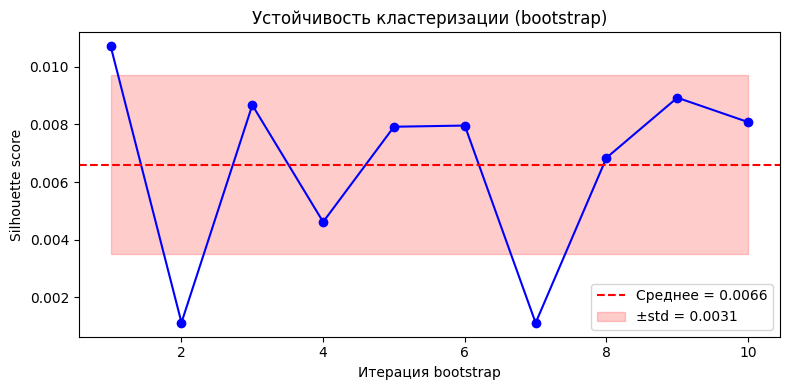

In [26]:
evaluate_clustering(train_embeddings_clean, train_labels_clean, n_bootstrap=10, sample_frac=0.8)

In [27]:
le = LabelEncoder()
artist_labels_clean = le.fit_transform(
    df_phillips_clean.loc[train_mask_clean, 'artist'].fillna('Unknown')
)

ari = adjusted_rand_score(artist_labels_clean, train_labels_clean)
v_measure = v_measure_score(artist_labels_clean, train_labels_clean)

print(f'Adjusted Rand Index (ARI):  {ari:.4f}')
print(f'V-measure:                  {v_measure:.4f}')
print()
print(f'ARI = {ari:.4f} — {"слабое" if abs(ari) < 0.1 else "умеренное" if abs(ari) < 0.3 else "сильное"} '
      f'совпадение кластеров с авторством')
print(f'V-measure = {v_measure:.4f} — {"слабое" if v_measure < 0.1 else "умеренное" if v_measure < 0.3 else "сильное"} '
      f'соответствие между кластерами и авторами')

Adjusted Rand Index (ARI):  0.0152
V-measure:                  0.3504

ARI = 0.0152 — слабое совпадение кластеров с авторством
V-measure = 0.3504 — сильное соответствие между кластерами и авторами


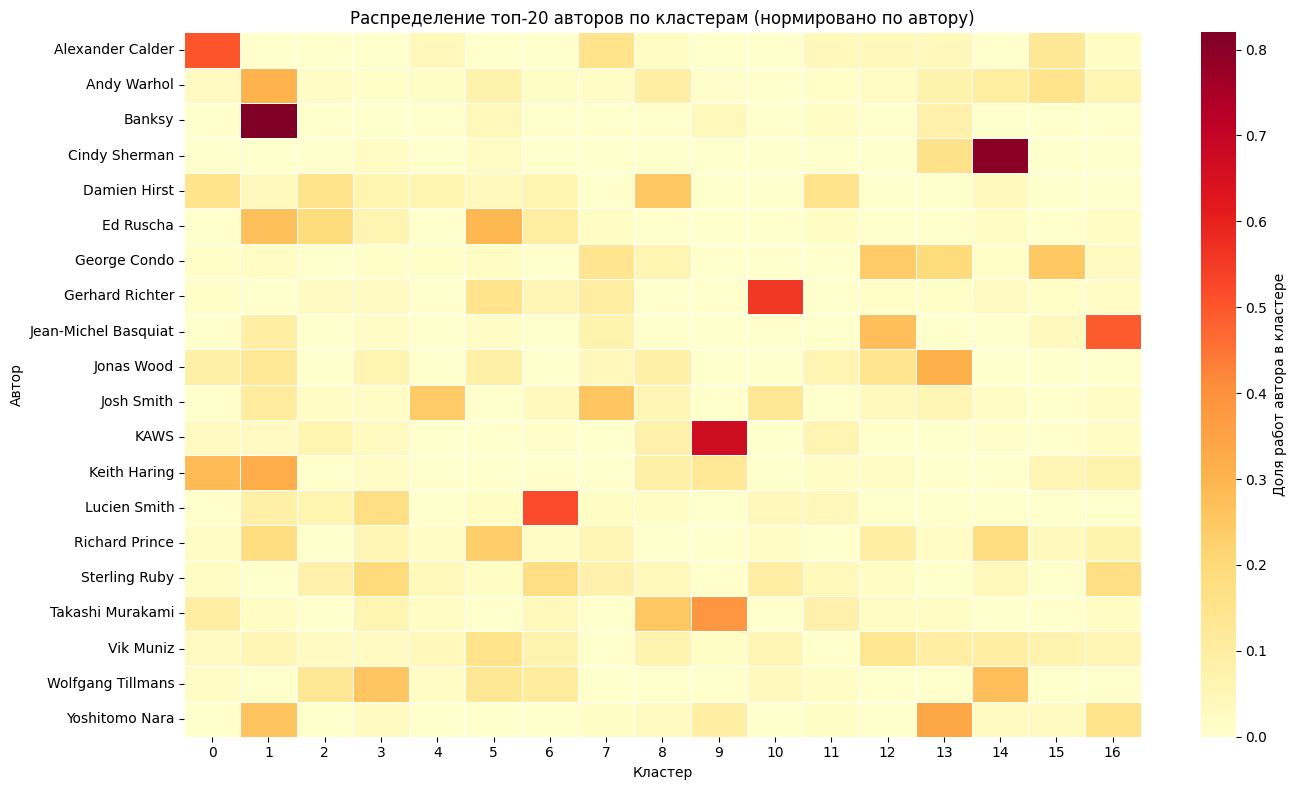

In [28]:
df_train_clean = df_phillips_clean[train_mask_clean].copy().reset_index(drop=True)
df_train_clean['cluster'] = train_labels_clean

top_artists = df_train_clean['artist'].value_counts().head(20).index.tolist()
df_top = df_train_clean[df_train_clean['artist'].isin(top_artists)].copy()

heatmap_data = df_top.groupby(['artist', 'cluster']).size().unstack(fill_value=0)
heatmap_norm = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)

plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_norm,
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Доля работ автора в кластере'}
)
plt.title('Распределение топ-20 авторов по кластерам (нормировано по автору)')
plt.xlabel('Кластер')
plt.ylabel('Автор')
plt.tight_layout()
plt.show()

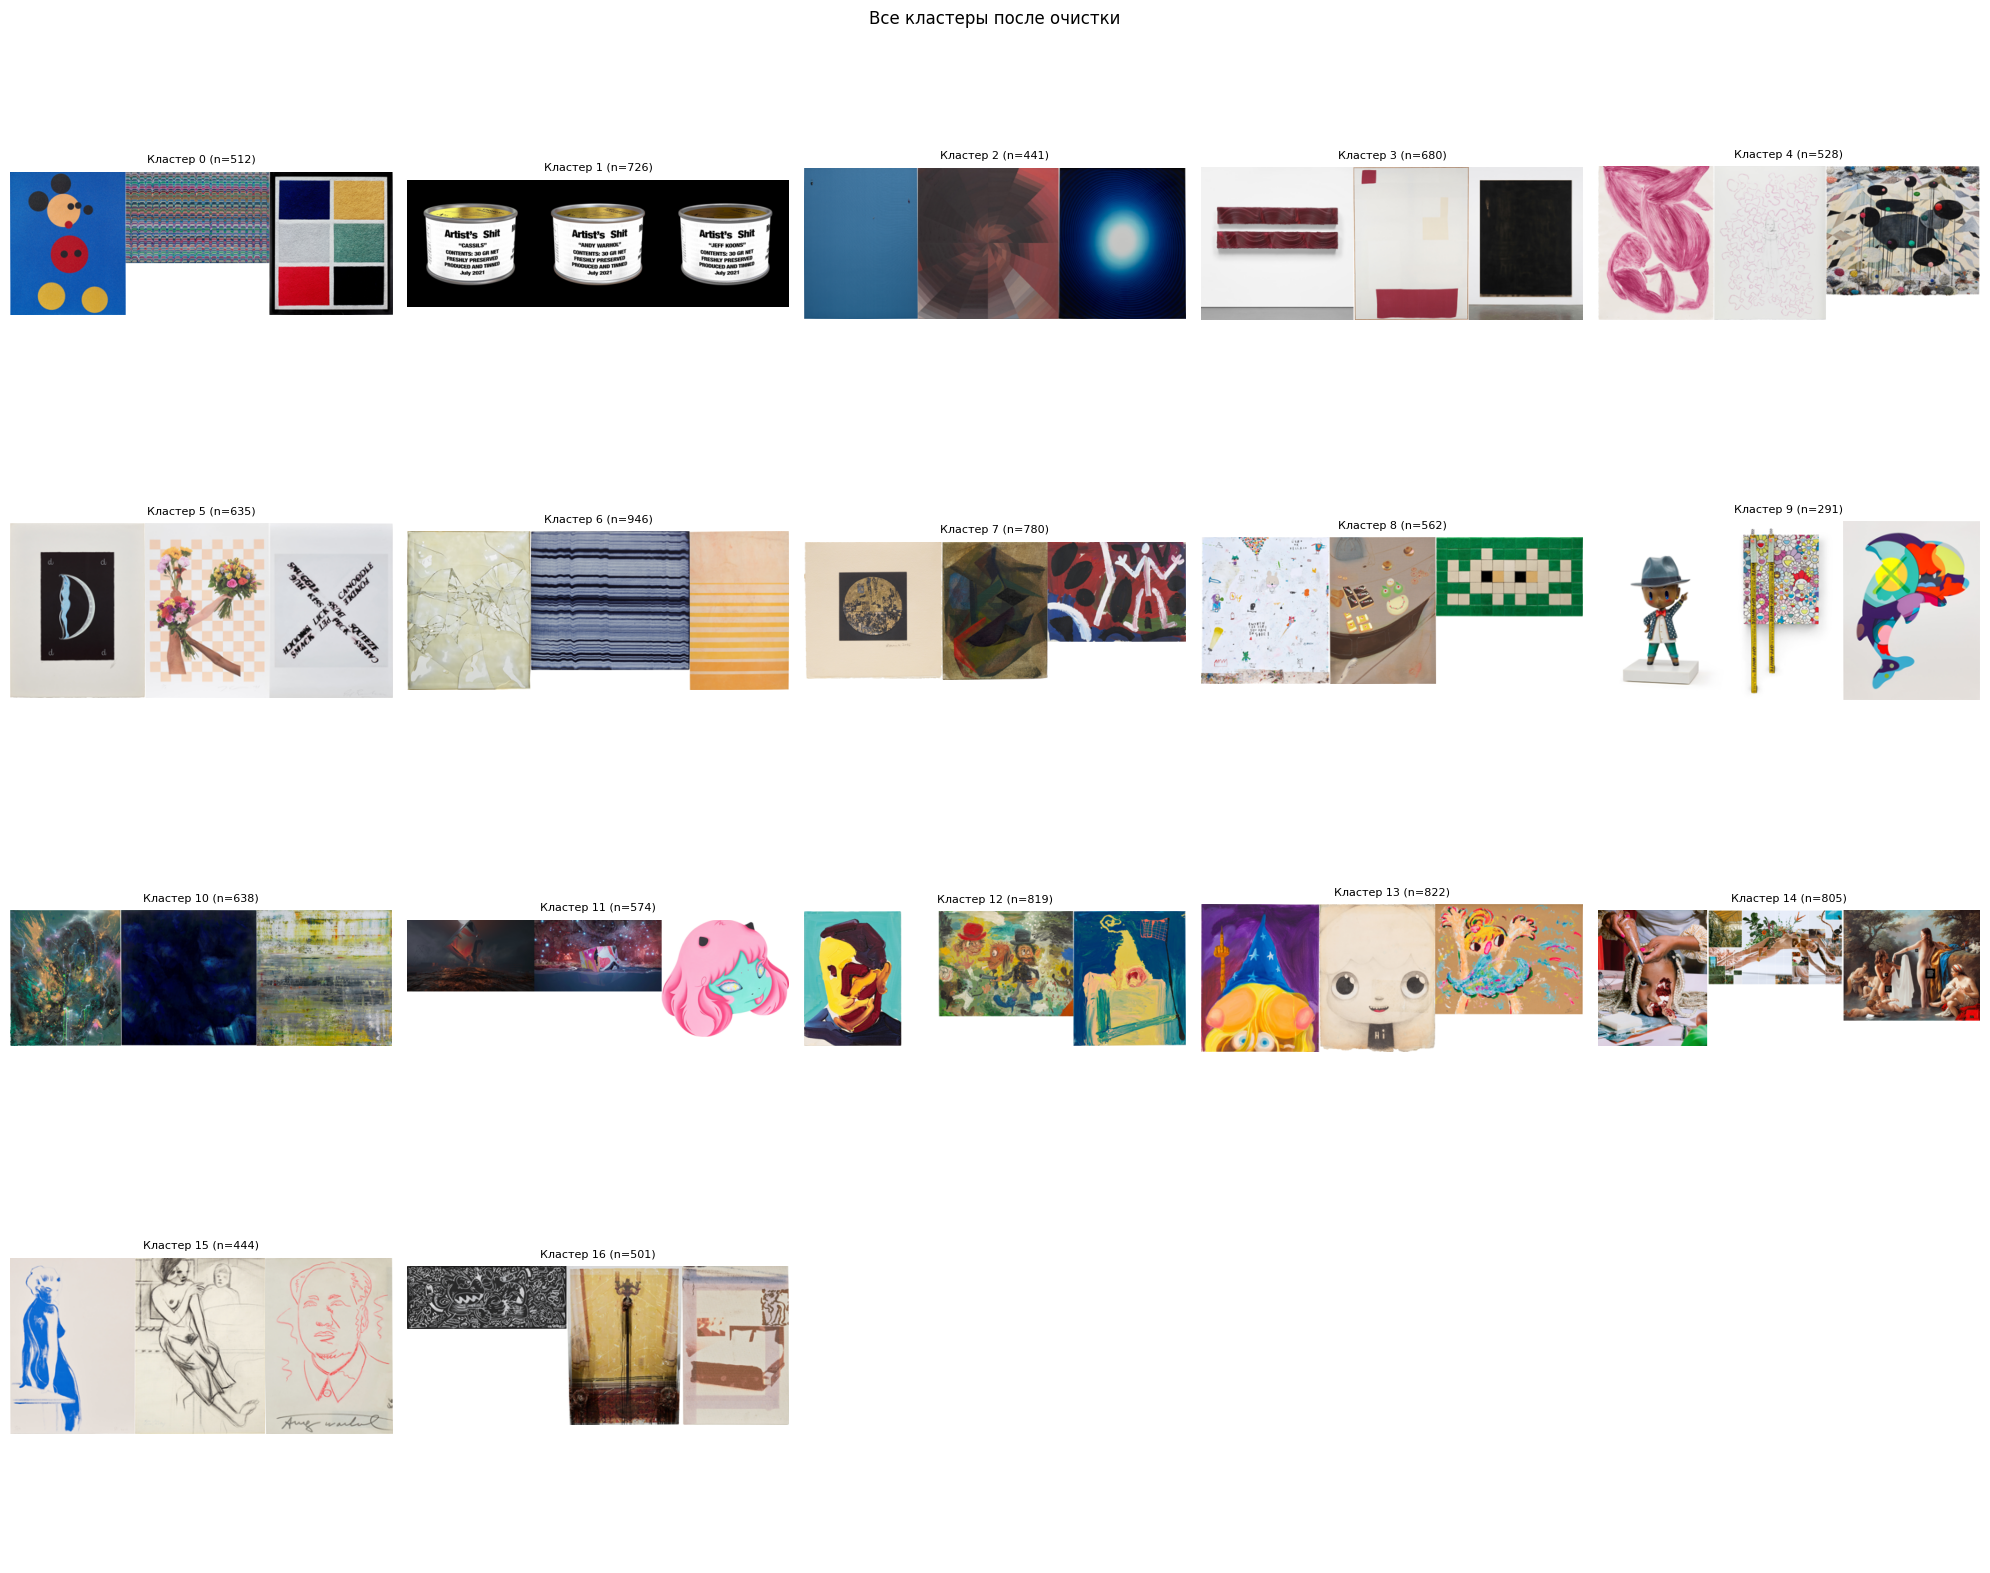

In [29]:
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for cluster_id in range(17):
    cluster_idx = np.where(train_labels_clean == cluster_id)[0]
    sample_idx = cluster_idx[:3]

    images = []
    for idx in sample_idx:
        img = Image.open(df_train_clean.iloc[idx]['local_image_path']).convert('RGB')
        img.thumbnail((200, 200))
        images.append(img)

    combined = Image.new('RGB', (sum(i.width for i in images), max(i.height for i in images)), (255, 255, 255))
    x_offset = 0
    for img in images:
        combined.paste(img, (x_offset, 0))
        x_offset += img.width

    axes[cluster_id].imshow(combined)
    axes[cluster_id].set_title(f'Кластер {cluster_id} (n={len(cluster_idx)})', fontsize=8)
    axes[cluster_id].axis('off')

# скрываем лишние оси
for i in range(17, len(axes)):
    axes[i].axis('off')

plt.suptitle('Все кластеры после очистки', fontsize=12)
plt.tight_layout()
plt.show()

In [43]:
df_phillips_clean['log_price'] = np.log1p(df_phillips_clean['price_usd_2026'])

In [44]:
def compute_cluster_density(labels: np.ndarray) -> np.ndarray:
    labels_series = pd.Series(labels)
    counts = labels_series.value_counts()
    return labels_series.map(counts).values


def compute_outlier_score(
    embeddings: np.ndarray,
    cluster_model,
    nearest_clusters_k: int = 5
) -> np.ndarray:
    '''Среднее расстояние до ближайших k центроидов — не зависит от цен и дат'''
    centers = np.asarray(cluster_model.cluster_centers_, dtype=np.float32)
    embeddings = np.asarray(embeddings, dtype=np.float32)
    nearest_clusters_k = max(1, min(nearest_clusters_k, centers.shape[0]))

    center_distances = np.linalg.norm(embeddings[:, None, :] - centers[None, :, :], axis=2)
    sorted_distances = np.sort(center_distances, axis=1)
    return np.mean(sorted_distances[:, :nearest_clusters_k], axis=1).astype(np.float32)


def compute_rolling_visual_uniformity(
    df: pd.DataFrame,
    embeddings: np.ndarray,
    labels: np.ndarray,
    date_col: str = 'auction_date_clean',
    max_cluster_sample: int = 200
) -> np.ndarray:
    '''
    Visual uniformity с rolling window по месяцам:
    для каждого лота в месяце M считаем попарные расстояния
    только по лотам того же кластера с датой < M.
    '''
    df = df.copy().reset_index(drop=True)
    df['_date'] = pd.to_datetime(df[date_col])
    df['_month'] = df['_date'].dt.to_period('M')

    unique_months = sorted(df['_month'].unique())
    visual_uniformity = np.full(len(df), np.nan, dtype=np.float32)

    for month in tqdm(unique_months, desc='Rolling visual uniformity'):
        current_mask = df['_month'] == month
        current_idx = np.where(current_mask)[0]

        if len(current_idx) == 0:
            continue

        ref_mask = df['_month'] < month
        ref_idx = np.where(ref_mask)[0]

        if len(ref_idx) == 0:
            continue

        for idx in current_idx:
            label = labels[idx]

            # референс — только лоты того же кластера с датой < M
            ref_same_cluster = ref_idx[labels[ref_idx] == label]

            if len(ref_same_cluster) <= 1:
                visual_uniformity[idx] = 0.0
                continue

            cluster_embeddings = embeddings[ref_same_cluster].astype(np.float32)
            if len(cluster_embeddings) > max_cluster_sample:
                cluster_embeddings = cluster_embeddings[:max_cluster_sample]

            pairwise = np.linalg.norm(
                cluster_embeddings[:, None, :] - cluster_embeddings[None, :, :], axis=2
            )
            upper_tri = np.triu_indices(len(cluster_embeddings), k=1)
            if len(upper_tri[0]) == 0:
                visual_uniformity[idx] = 0.0
            else:
                visual_uniformity[idx] = float(np.mean(pairwise[upper_tri]))

    nan_count = np.isnan(visual_uniformity).sum()
    print(f'NaN в visual_uniformity (первые месяцы без референса): {nan_count}')

    return visual_uniformity

def _calculate_luxury_anchor_feature(
    current_embeddings: np.ndarray,
    current_labels: np.ndarray,
    reference_embeddings: np.ndarray,
    reference_labels: np.ndarray,
    reference_prices: np.ndarray,
    luxury_anchor_percent: float = 0.01
) -> pd.DataFrame:

    if len(reference_embeddings) == 0:
        return pd.DataFrame({
            'luxury_anchor_distance': np.full(len(current_embeddings), np.nan, dtype=np.float32)
        })

    valid_price_mask = np.isfinite(reference_prices)
    ref_embeddings_valid = reference_embeddings[valid_price_mask]
    ref_labels_valid = reference_labels[valid_price_mask]
    ref_prices_valid = reference_prices[valid_price_mask].astype(np.float32)

    cluster_anchor_embeddings = {}
    for label in np.unique(ref_labels_valid):
        cluster_mask = ref_labels_valid == label
        cluster_embeddings = ref_embeddings_valid[cluster_mask]
        cluster_prices = ref_prices_valid[cluster_mask]
        anchors_count = max(1, int(math.ceil(len(cluster_embeddings) * luxury_anchor_percent)))
        top_anchor_indices = np.argsort(cluster_prices)[-anchors_count:]
        cluster_anchor_embeddings[label] = cluster_embeddings[top_anchor_indices]

    luxury_anchor_distances = np.full(len(current_embeddings), np.nan, dtype=np.float32)
    for row_idx, (embedding, label) in enumerate(zip(current_embeddings, current_labels)):
        anchors = cluster_anchor_embeddings.get(label)
        if anchors is None or len(anchors) == 0:
            continue
        distances = np.linalg.norm(anchors - embedding, axis=1)
        luxury_anchor_distances[row_idx] = float(np.min(distances))

    return pd.DataFrame({'luxury_anchor_distance': luxury_anchor_distances})

In [45]:
class SimilarityFeature:
    def __init__(self, n_expensive_refs=10, n_cheap_refs=10, n_neighbors=15):
        self.n_expensive_refs = n_expensive_refs
        self.n_cheap_refs = n_cheap_refs
        self.n_neighbors = n_neighbors
        self.expensive_refs = None
        self.cheap_refs = None
        self.expensive_prices = None
        self.cheap_prices = None
        self.knn_model = None
        self.train_prices = None
        self.is_fitted = False

    def fit(self, embeddings: np.ndarray, prices: np.ndarray):
        print(f"Fitting SimilarityFeature на {len(embeddings)} образцах...")
        embeddings_norm = normalize(embeddings, norm='l2')
        self.train_prices = prices.copy()

        sorted_idx = np.argsort(prices)

        expensive_idx = sorted_idx[-self.n_expensive_refs:]
        self.expensive_refs = embeddings_norm[expensive_idx]
        self.expensive_prices = prices[expensive_idx]

        cheap_idx = sorted_idx[:self.n_cheap_refs]
        self.cheap_refs = embeddings_norm[cheap_idx]
        self.cheap_prices = prices[cheap_idx]

        self.knn_model = NearestNeighbors(
            n_neighbors=self.n_neighbors + 1,
            metric='cosine',
            algorithm='brute',
            n_jobs=-1
        )
        self.knn_model.fit(embeddings_norm)
        self.is_fitted = True
        print(f"Fitted. Референсы: {self.n_expensive_refs} дорогих, {self.n_cheap_refs} дешёвых")
        return self

    def transform(self, embeddings: np.ndarray, verbose=True) -> pd.DataFrame:
        if not self.is_fitted:
            raise ValueError("Сначала вызовите fit()")
        if verbose:
            print(f"Transforming {len(embeddings)} образцов...")

        embeddings_norm = normalize(embeddings, norm='l2')
        features = []
        feature_names = []

        sim_expensive = np.dot(embeddings_norm, self.expensive_refs.T)
        features.append(np.mean(sim_expensive, axis=1))
        feature_names.append('avg_sim_to_expensive')
        features.append(np.max(sim_expensive, axis=1))
        feature_names.append('max_sim_to_elite')

        sim_cheap = np.dot(embeddings_norm, self.cheap_refs.T)
        features.append(np.mean(sim_cheap, axis=1))
        feature_names.append('avg_sim_to_cheap')
        features.append(np.min(sim_cheap, axis=1))
        feature_names.append('min_sim_to_cheap')

        distances, indices = self.knn_model.kneighbors(embeddings_norm)
        neighbor_prices = self.train_prices[indices[:, 1:]]

        features.append(np.mean(neighbor_prices, axis=1))
        feature_names.append('knn_mean_price')
        features.append(np.median(neighbor_prices, axis=1))
        feature_names.append('knn_median_price')
        features.append(np.std(neighbor_prices, axis=1))
        feature_names.append('knn_std_price')

        result_df = pd.DataFrame(np.column_stack(features), columns=feature_names)
        if verbose:
            print(f"Создано {len(feature_names)} признаков: {feature_names}")
        return result_df

In [46]:
def compute_rolling_similarity_features(
    df: pd.DataFrame,
    embeddings: np.ndarray,
    labels: np.ndarray,
    distances: np.ndarray,
    price_col: str = 'price_usd_2026',
    date_col: str = 'auction_date_clean',
    n_expensive_refs: int = 10,
    n_cheap_refs: int = 10,
    n_neighbors: int = 15,
    luxury_anchor_percent: float = 0.01
) -> pd.DataFrame:
    '''
    Для каждого месяца M считает similarity-признаки используя как референс
    только лоты из месяцев < M. Исключает утечку будущих цен.
    '''
    df = df.copy().reset_index(drop=True)
    df['_date'] = pd.to_datetime(df[date_col])
    df['_month'] = df['_date'].dt.to_period('M')
    df['_labels'] = labels
    df['_distances'] = distances

    unique_months = sorted(df['_month'].unique())

    # инициализируем результирующие массивы
    n = len(df)
    avg_sim_to_expensive = np.full(n, np.nan)
    max_sim_to_elite = np.full(n, np.nan)
    avg_sim_to_cheap = np.full(n, np.nan)
    min_sim_to_cheap = np.full(n, np.nan)
    knn_mean_price = np.full(n, np.nan)
    knn_median_price = np.full(n, np.nan)
    knn_std_price = np.full(n, np.nan)
    luxury_anchor_dist = np.full(n, np.nan)

    for i, month in enumerate(tqdm(unique_months, desc='Rolling monthly features')):
        # текущий месяц
        current_mask = df['_month'] == month
        current_idx = np.where(current_mask)[0]

        if len(current_idx) == 0:
            continue

        # референс — все лоты строго до текущего месяца
        ref_mask = df['_month'] < month
        ref_idx = np.where(ref_mask)[0]

        if len(ref_idx) < max(n_expensive_refs, n_cheap_refs, n_neighbors + 1):
            # недостаточно референсов — пропускаем (первые месяцы)
            continue

        ref_embeddings = embeddings[ref_idx]
        ref_prices = df.loc[ref_idx, price_col].values
        ref_labels = labels[ref_idx]

        current_embeddings = embeddings[current_idx]
        current_labels = labels[current_idx]

        # L2 нормализация
        ref_norm = normalize(ref_embeddings, norm='l2')
        cur_norm = normalize(current_embeddings, norm='l2')

        # similarity с дорогими
        sorted_price_idx = np.argsort(ref_prices)
        expensive_idx = sorted_price_idx[-n_expensive_refs:]
        cheap_idx = sorted_price_idx[:n_cheap_refs]

        expensive_refs = ref_norm[expensive_idx]
        cheap_refs = ref_norm[cheap_idx]

        sim_exp = np.dot(cur_norm, expensive_refs.T)
        avg_sim_to_expensive[current_idx] = np.mean(sim_exp, axis=1)
        max_sim_to_elite[current_idx] = np.max(sim_exp, axis=1)

        sim_cheap = np.dot(cur_norm, cheap_refs.T)
        avg_sim_to_cheap[current_idx] = np.mean(sim_cheap, axis=1)
        min_sim_to_cheap[current_idx] = np.min(sim_cheap, axis=1)

        # KNN
        k = min(n_neighbors + 1, len(ref_idx))
        knn = NearestNeighbors(n_neighbors=k, metric='cosine', algorithm='brute', n_jobs=-1)
        knn.fit(ref_norm)
        _, indices = knn.kneighbors(cur_norm)

        neighbor_prices = ref_prices[indices[:, :k]]
        knn_mean_price[current_idx] = np.mean(neighbor_prices, axis=1)
        knn_median_price[current_idx] = np.median(neighbor_prices, axis=1)
        knn_std_price[current_idx] = np.std(neighbor_prices, axis=1)

        # luxury anchor distance
        luxury_df = _calculate_luxury_anchor_feature(
            current_embeddings=current_embeddings,
            current_labels=current_labels,
            reference_embeddings=ref_embeddings,
            reference_labels=ref_labels,
            reference_prices=ref_prices,
            luxury_anchor_percent=luxury_anchor_percent
        )
        luxury_anchor_dist[current_idx] = luxury_df['luxury_anchor_distance'].values

    result = pd.DataFrame({
        'avg_sim_to_expensive': avg_sim_to_expensive,
        'max_sim_to_elite': max_sim_to_elite,
        'avg_sim_to_cheap': avg_sim_to_cheap,
        'min_sim_to_cheap': min_sim_to_cheap,
        'knn_mean_price': knn_mean_price,
        'knn_median_price': knn_median_price,
        'knn_std_price': knn_std_price,
        'luxury_anchor_distance': luxury_anchor_dist
    })

    nan_counts = result.isnull().sum()
    print(f'NaN по признакам (первые месяцы без референса):\n{nan_counts}')

    return result

In [47]:
train_df = df_phillips_clean[train_mask_clean].reset_index(drop=True)
train_prices = train_df['log_price'].values

# 1. outlier_score (без rolling, не зависит от цен)
print('Считаем outlier_score...')
train_outlier_score = compute_outlier_score(train_embeddings_clean, clustering_model_clean)

# 2. cluster_density (без rolling)
print('Считаем cluster_density...')
train_cluster_density = compute_cluster_density(train_labels_clean)

# 3. visual_uniformity (rolling window)
print('Считаем visual_uniformity...')
train_visual_uniformity = compute_rolling_visual_uniformity(
    df=train_df,
    embeddings=train_embeddings_clean,
    labels=train_labels_clean
)

# 4. similarity + luxury_anchor (rolling window)
print('Считаем rolling similarity features...')
train_rolling_sim = compute_rolling_similarity_features(
    df=train_df,
    embeddings=train_embeddings_clean,
    labels=train_labels_clean,
    distances=train_distances_clean,
    price_col='log_price'
)

print('Готово!')

Считаем outlier_score...
Считаем cluster_density...
Считаем visual_uniformity...


Rolling visual uniformity:   0%|          | 0/64 [00:00<?, ?it/s]

NaN в visual_uniformity (первые месяцы без референса): 95
Считаем rolling similarity features...


Rolling monthly features:   0%|          | 0/64 [00:00<?, ?it/s]

NaN по признакам (первые месяцы без референса):
avg_sim_to_expensive      95
max_sim_to_elite          95
avg_sim_to_cheap          95
min_sim_to_cheap          95
knn_mean_price            95
knn_median_price          95
knn_std_price             95
luxury_anchor_distance    96
dtype: int64
Готово!


In [48]:
# проверяем размерности
print(f'train_outlier_score: {train_outlier_score.shape}')
print(f'train_cluster_density: {train_cluster_density.shape}')
print(f'train_visual_uniformity: {train_visual_uniformity.shape}')
print(f'train_rolling_sim: {train_rolling_sim.shape}')
print()

# проверяем значения на нескольких примерах
idx = 500
print(f'Пример лота (idx={idx}):')
print(f'  artist: {train_df.iloc[idx]["artist"]}')
print(f'  price: {train_df.iloc[idx]["price_usd_2026"]:.0f}')
print(f'  cluster: {train_labels_clean[idx]}')
print(f'  outlier_score: {train_outlier_score[idx]:.4f}')
print(f'  cluster_density: {train_cluster_density[idx]}')
print(f'  visual_uniformity: {train_visual_uniformity[idx]:.4f}')
print(f'  luxury_anchor_distance: {train_rolling_sim["luxury_anchor_distance"].iloc[idx]:.4f}')
print(f'  knn_mean_price: {train_rolling_sim["knn_mean_price"].iloc[idx]:.0f}')
print(f'  avg_sim_to_expensive: {train_rolling_sim["avg_sim_to_expensive"].iloc[idx]:.4f}')

train_outlier_score: (10704,)
train_cluster_density: (10704,)
train_visual_uniformity: (10704,)
train_rolling_sim: (10704, 8)

Пример лота (idx=500):
  artist: Josh Sperling
  price: 21187
  cluster: 11
  outlier_score: 27.5779
  cluster_density: 574
  visual_uniformity: 33.6482
  luxury_anchor_distance: 33.5680
  knn_mean_price: 11
  avg_sim_to_expensive: -0.0802


In [49]:
# берём несколько лотов и проверяем что их rolling-признаки считались только по прошлому
train_df_check = train_df.copy()
train_df_check['_month'] = pd.to_datetime(train_df_check['auction_date_clean']).dt.to_period('M')
train_df_check['knn_mean_price'] = train_rolling_sim['knn_mean_price'].values
train_df_check['avg_sim_to_expensive'] = train_rolling_sim['avg_sim_to_expensive'].values

# для каждого из 5 случайных месяцев проверяем что референс < текущего месяца
check_months = sorted(train_df_check['_month'].unique())[10:15]  # пропускаем первые NaN-месяцы

print('Проверка временного порядка:')
for month in check_months:
    current = train_df_check[train_df_check['_month'] == month]
    ref = train_df_check[train_df_check['_month'] < month]

    print(f'\nМесяц {month}: {len(current)} лотов, референс: {len(ref)} лотов')
    print(f'  Макс дата в референсе: {ref["auction_date_clean"].max()}')
    print(f'  Мин дата в текущем:    {current["auction_date_clean"].min()}')
    print(f'  Порядок соблюдён:      {ref["auction_date_clean"].max() < current["auction_date_clean"].min()}')

Проверка временного порядка:

Месяц 2014-05: 172 лотов, референс: 1244 лотов
  Макс дата в референсе: 2014-04-08
  Мин дата в текущем:    2014-05-15
  Порядок соблюдён:      True

Месяц 2014-07: 128 лотов, референс: 1416 лотов
  Макс дата в референсе: 2014-05-16
  Мин дата в текущем:    2014-07-02
  Порядок соблюдён:      True

Месяц 2014-09: 171 лотов, референс: 1544 лотов
  Макс дата в референсе: 2014-07-03
  Мин дата в текущем:    2014-09-16
  Порядок соблюдён:      True

Месяц 2014-10: 143 лотов, референс: 1715 лотов
  Макс дата в референсе: 2014-09-16
  Мин дата в текущем:    2014-10-15
  Порядок соблюдён:      True

Месяц 2014-11: 151 лотов, референс: 1858 лотов
  Макс дата в референсе: 2014-10-16
  Мин дата в текущем:    2014-11-13
  Порядок соблюдён:      True


In [50]:
train_df_check['luxury_anchor_distance'] = train_rolling_sim['luxury_anchor_distance'].values

# смотрим в каких месяцах NaN
nan_mask = train_rolling_sim['knn_mean_price'].isna()
nan_months = train_df_check.loc[nan_mask.values, '_month'].value_counts().sort_index()

print('Месяцы с NaN значениями:')
print(nan_months)
print(f'\nВсего NaN лотов: {nan_mask.sum()}')
print(f'Последний месяц с NaN: {nan_months.index.max()}')
print(f'Первый месяц без NaN: {sorted(train_df_check[~nan_mask.values]["_month"].unique())[0]}')

Месяцы с NaN значениями:
_month
2013-04    95
Freq: M, Name: count, dtype: int64

Всего NaN лотов: 95
Последний месяц с NaN: 2013-04
Первый месяц без NaN: 2013-05


In [51]:
train_df_check2 = train_df.copy()
for col in train_rolling_sim.columns:
    train_df_check2[col] = train_rolling_sim[col].values
train_df_check2['outlier_score'] = train_outlier_score
train_df_check2['cluster_density'] = train_cluster_density
train_df_check2['visual_uniformity'] = train_visual_uniformity
train_df_check2['labels'] = train_labels_clean

# топ-5 самых дорогих лотов
top5_expensive = train_df_check2.nlargest(5, 'price_usd_2026')[
    ['artist', 'title', 'price_usd_2026', 'avg_sim_to_expensive',
     'max_sim_to_elite', 'luxury_anchor_distance', 'knn_mean_price']
]
print('Топ-5 самых дорогих лотов:')
print(top5_expensive.to_string())

print()

# топ-5 самых дешёвых лотов
top5_cheap = train_df_check2.nsmallest(5, 'price_usd_2026')[
    ['artist', 'title', 'price_usd_2026', 'avg_sim_to_expensive',
     'max_sim_to_elite', 'luxury_anchor_distance', 'knn_mean_price']
]
print('Топ-5 самых дешёвых лотов:')
print(top5_cheap.to_string())

Топ-5 самых дорогих лотов:
                     artist                         title  price_usd_2026  avg_sim_to_expensive  max_sim_to_elite  luxury_anchor_distance  knn_mean_price
9441            Mark Rothko  Untitled (Red, Blue, Orange)    8.486917e+07              0.014061          0.099608               35.099552       11.026451
5275          Pablo Picasso                   La Dormeuse    7.800714e+07              0.036866          0.357725               25.796915       10.791730
10600           Andy Warhol                 Four Marilyns    5.981350e+07              0.062162          0.240221               36.525990        9.434021
4815   Jean-Michel Basquiat                      Flexible    5.967120e+07              0.066096          0.476056               23.528601       11.905490
1084          David Hockney                Nichols Canyon    5.048244e+07              0.053867          0.245867               28.865856       11.486433

Топ-5 самых дешёвых лотов:
                artis

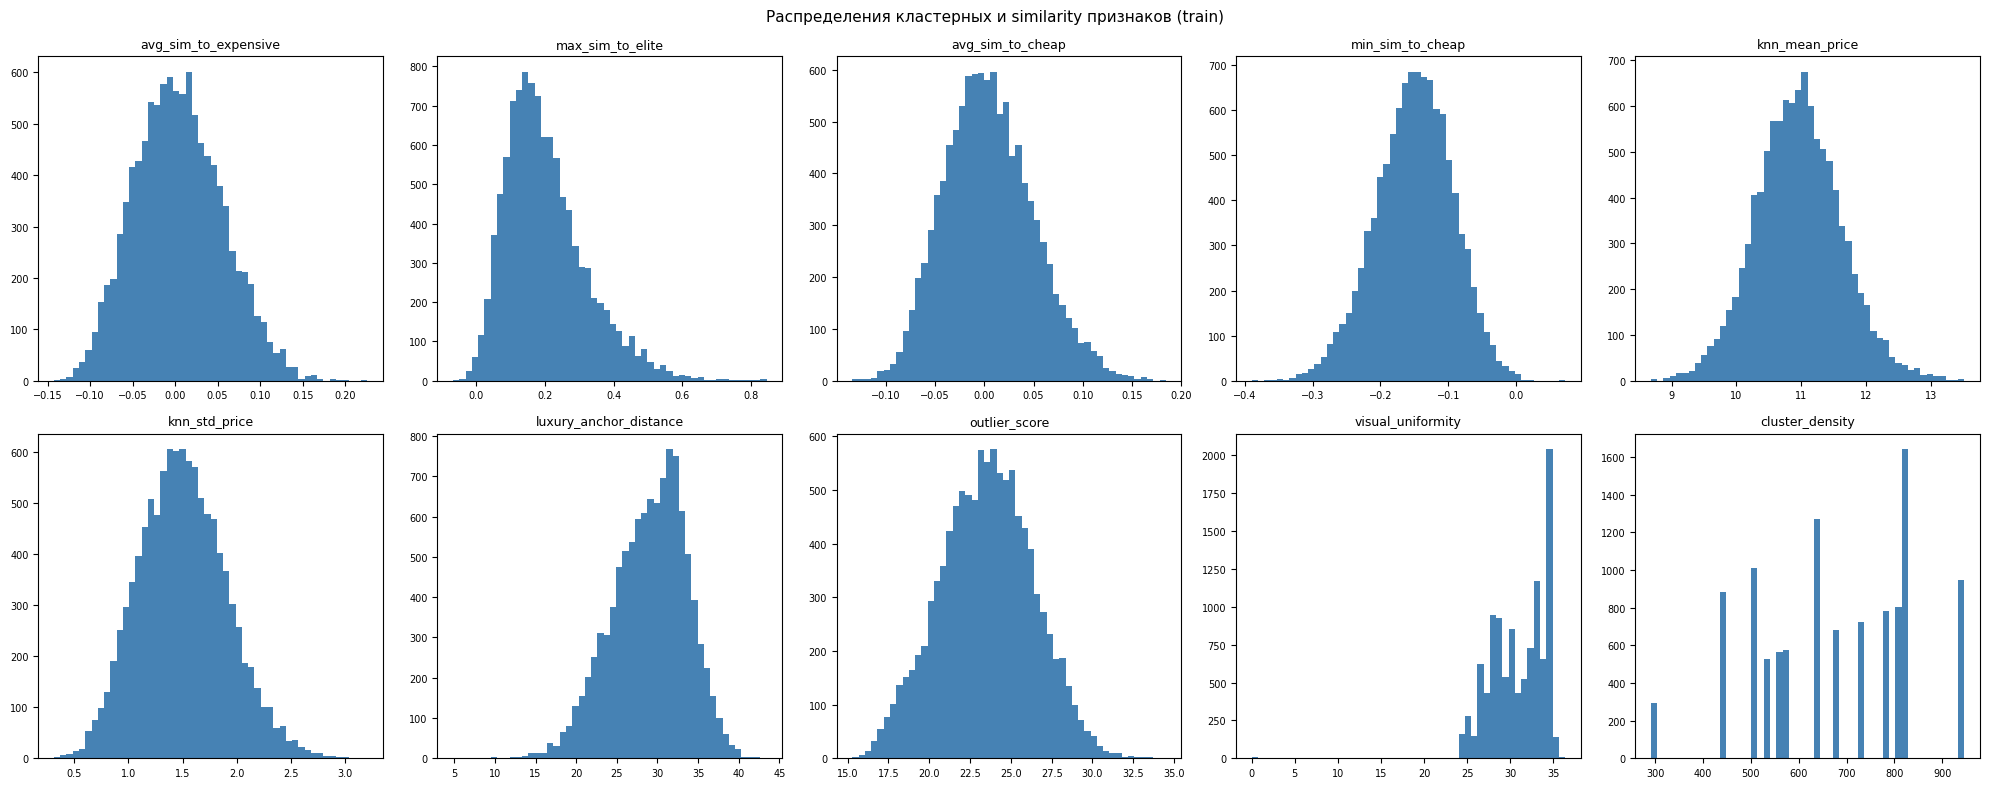

In [52]:
feature_cols = [
    'avg_sim_to_expensive', 'max_sim_to_elite', 'avg_sim_to_cheap',
    'min_sim_to_cheap', 'knn_mean_price', 'knn_std_price',
    'luxury_anchor_distance', 'outlier_score', 'visual_uniformity', 'cluster_density'
]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    data = train_df_check2[col].dropna()
    axes[i].hist(data, bins=50, color='steelblue', edgecolor='none')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=7)

plt.suptitle('Распределения кластерных и similarity признаков (train)', fontsize=11)
plt.tight_layout()
plt.show()

In [53]:
df_train_features = pd.concat([
    train_df,
    df_visual_clean[train_mask_clean].reset_index(drop=True).drop(columns=['local_image_path']),
    pd.DataFrame({
        'labels': train_labels_clean,
        'distances_to_center': train_distances_clean,
        'cluster_density': train_cluster_density,
        'outlier_score': train_outlier_score,
        'visual_uniformity': train_visual_uniformity
    }),
    train_rolling_sim.reset_index(drop=True)
], axis=1)

df_train_features['split'] = 'train'

print(f'Train датафрейм: {df_train_features.shape}')
print(df_train_features.columns.tolist())

Train датафрейм: (10704, 51)
['auction_title', 'auction_url', 'auction_date', 'lot_url', 'lot_number', 'artist', 'title', 'estimate', 'price', 'currency', 'image_url', 'estimate_low', 'estimate_high', 'currency_code', 'auction_date_clean', 'date_obj', 'year', 'month', 'price_usd_raw', 'price_usd_2026', 'applied_rate', 'estimate_low_usd_2026', 'estimate_high_usd_2026', 'local_image_path', 'date', 'split', 'log_price', 'aspect_ratio', 'colorfulness', 'saturation', 'bright', 'contrast', 'entropy', 'warmth', 'hue_std', 'short_wave_ratio', 'mid_wave_ratio', 'long_wave_ratio', 'labels', 'distances_to_center', 'cluster_density', 'outlier_score', 'visual_uniformity', 'avg_sim_to_expensive', 'max_sim_to_elite', 'avg_sim_to_cheap', 'min_sim_to_cheap', 'knn_mean_price', 'knn_median_price', 'knn_std_price', 'luxury_anchor_distance']


In [54]:
# проверяем корректность склейки — берём несколько случайных индексов
# и сверяем признаки напрямую из источников с тем что попало в df_train_features

check_indices = [0, 100, 500, 1000, 5000]

print('Проверка корректности склейки:\n')
for idx in check_indices:
    print(f'--- idx={idx} ---')

    # визуальные признаки
    feat_from_df = df_train_features.iloc[idx]['aspect_ratio']
    feat_from_source = df_visual_clean[train_mask_clean].reset_index(drop=True).iloc[idx]['aspect_ratio']
    print(f'aspect_ratio: df={feat_from_df}, source={feat_from_source}, match={np.isclose(feat_from_df, feat_from_source)}')

    # кластерные признаки
    label_from_df = df_train_features.iloc[idx]['labels']
    label_from_source = train_labels_clean[idx]
    print(f'labels: df={label_from_df}, source={label_from_source}, match={label_from_df == label_from_source}')

    # similarity признаки
    knn_from_df = df_train_features.iloc[idx]['knn_mean_price']
    knn_from_source = train_rolling_sim.iloc[idx]['knn_mean_price']
    print(f'knn_mean_price: df={knn_from_df:.4f}, source={knn_from_source:.4f}, match={np.isclose(knn_from_df, knn_from_source)}')

    # artist совпадает с исходным df
    artist_from_df = df_train_features.iloc[idx]['artist']
    artist_from_source = train_df.iloc[idx]['artist']
    print(f'artist: df={artist_from_df}, source={artist_from_source}, match={artist_from_df == artist_from_source}')
    print()

Проверка корректности склейки:

--- idx=0 ---
aspect_ratio: df=0.801, source=0.801, match=True
labels: df=14, source=14, match=True
knn_mean_price: df=9.4183, source=9.4183, match=True
artist: df=Slimesunday, source=Slimesunday, match=True

--- idx=100 ---
aspect_ratio: df=0.938, source=0.938, match=True
labels: df=12, source=12, match=True
knn_mean_price: df=10.8973, source=10.8973, match=True
artist: df=Erik Parker, source=Erik Parker, match=True

--- idx=500 ---
aspect_ratio: df=1.0, source=1.0, match=True
labels: df=11, source=11, match=True
knn_mean_price: df=11.0947, source=11.0947, match=True
artist: df=Josh Sperling, source=Josh Sperling, match=True

--- idx=1000 ---
aspect_ratio: df=2.612, source=2.612, match=True
labels: df=0, source=0, match=True
knn_mean_price: df=11.4773, source=11.4773, match=True
artist: df=Alexander Calder, source=Alexander Calder, match=True

--- idx=5000 ---
aspect_ratio: df=0.938, source=0.938, match=True
labels: df=12, source=12, match=True
knn_mean

In [55]:
# Josh Sperling находится на idx=500 в train
idx = 500
row = train_df.iloc[idx]

print(f'Artist: {row["artist"]}')
print(f'Title: {row["title"]}')
print(f'Price: {row["price_usd_2026"]:.0f} (log: {row["log_price"]:.3f})')
print(f'Date: {row["auction_date_clean"]}')
print(f'Cluster: {train_labels_clean[idx]}')

# смотрим сколько референсов было доступно в его месяце
month = pd.to_datetime(row['auction_date_clean']).to_period('M')
ref_mask = pd.to_datetime(train_df['auction_date_clean']).dt.to_period('M') < month
n_refs = ref_mask.sum()
print(f'\nМесяц: {month}')
print(f'Доступно референсов: {n_refs}')

# находим его KNN-соседей вручную
ref_idx = np.where(ref_mask)[0]
ref_embeddings = train_embeddings_clean[ref_idx]
ref_norm = normalize(ref_embeddings, norm='l2')
cur_norm = normalize(train_embeddings_clean[idx:idx+1], norm='l2')

knn = NearestNeighbors(n_neighbors=16, metric='cosine', algorithm='brute', n_jobs=-1)
knn.fit(ref_norm)
distances, indices = knn.kneighbors(cur_norm)

neighbor_idx = ref_idx[indices[0][1:16]]
neighbors = train_df.iloc[neighbor_idx][['artist', 'title', 'price_usd_2026', 'auction_date_clean']].copy()
neighbors['log_price'] = train_df.iloc[neighbor_idx]['log_price'].values
neighbors['cosine_dist'] = distances[0][1:16]

print(f'\nТоп-15 соседей Josh Sperling:')
print(neighbors.to_string())
print(f'\nСреднее log_price соседей: {neighbors["log_price"].mean():.3f}')
print(f'Среднее price соседей: {neighbors["price_usd_2026"].mean():.0f}')

Artist: Josh Sperling
Title: Best of All Possible Worlds #10
Price: 21187 (log: 9.961)
Date: 2021-03-30
Cluster: 11

Месяц: 2021-03
Доступно референсов: 10028

Топ-15 соседей Josh Sperling:
                  artist                                  title  price_usd_2026 auction_date_clean  log_price  cosine_dist
2866       Josh Sperling                          Blue Squiggle    41349.076040         2019-11-13  10.629830     0.413890
9909            Guy Mees                        Verloren Ruimte    20980.878156         2013-12-11   9.951414     0.479221
4237   Agostino Bonalumi                                 Bianco   315866.028817         2018-10-05  12.663077     0.495100
8581         Turi Simeti                               Untitled    82123.296595         2015-05-13  11.315989     0.505885
6672   Wolfgang Tillmans                        Paper Drop-Haze    36415.040765         2016-10-06  10.502765     0.524044
5886   Agostino Bonalumi                          Bianco e Nero   401509

In [56]:
df_train_features.to_csv('/content/drive/MyDrive/phillips_train_features.csv', index=False)
print('Сохранено: phillips_train_features.csv')

Сохранено: phillips_train_features.csv


In [57]:
val_df = df_phillips_clean[val_mask_clean].reset_index(drop=True)
val_prices = val_df['log_price'].values

# 1. outlier_score
print('Считаем outlier_score...')
val_outlier_score = compute_outlier_score(val_embeddings_clean, clustering_model_clean)

# 2. cluster_density
print('Считаем cluster_density...')
val_cluster_density = compute_cluster_density(val_labels_clean)

# 3. visual_uniformity (rolling — референс только train)
print('Считаем visual_uniformity...')
val_visual_uniformity = compute_rolling_visual_uniformity(
    df=pd.concat([train_df, val_df]).reset_index(drop=True),
    embeddings=np.vstack([train_embeddings_clean, val_embeddings_clean]),
    labels=np.concatenate([train_labels_clean, val_labels_clean])
)
# берём только val часть
val_visual_uniformity = val_visual_uniformity[len(train_df):]

# 4. similarity признаки (fit на train, transform на val)
print('Считаем similarity features...')
sim_feature = SimilarityFeature(n_expensive_refs=10, n_cheap_refs=10, n_neighbors=15)
sim_feature.fit(train_embeddings_clean, train_df['log_price'].values)
val_sim = sim_feature.transform(val_embeddings_clean)

# 5. luxury_anchor (референс = весь train)
print('Считаем luxury_anchor_distance...')
val_luxury = _calculate_luxury_anchor_feature(
    current_embeddings=val_embeddings_clean,
    current_labels=val_labels_clean,
    reference_embeddings=train_embeddings_clean,
    reference_labels=train_labels_clean,
    reference_prices=train_df['log_price'].values,
    luxury_anchor_percent=0.01
)

print('Готово!')

Считаем outlier_score...
Считаем cluster_density...
Считаем visual_uniformity...


Rolling visual uniformity:   0%|          | 0/85 [00:00<?, ?it/s]

NaN в visual_uniformity (первые месяцы без референса): 95
Считаем similarity features...
Fitting SimilarityFeature на 10704 образцах...
Fitted. Референсы: 10 дорогих, 10 дешёвых
Transforming 4870 образцов...
Создано 7 признаков: ['avg_sim_to_expensive', 'max_sim_to_elite', 'avg_sim_to_cheap', 'min_sim_to_cheap', 'knn_mean_price', 'knn_median_price', 'knn_std_price']
Считаем luxury_anchor_distance...
Готово!


Rolling на всем датасете

In [58]:
# полные метки и расстояния по всему датасету
all_labels_full = np.empty(len(df_phillips_clean), dtype=int)
all_labels_full[train_mask_clean] = train_labels_clean
all_labels_full[val_mask_clean] = val_labels_clean
all_labels_full[test_mask_clean] = test_labels_clean

all_distances_full = np.empty(len(df_phillips_clean))
all_distances_full[train_mask_clean] = train_distances_clean
all_distances_full[val_mask_clean] = val_distances_clean
all_distances_full[test_mask_clean] = test_distances_clean

print(f'Полный датасет: {len(df_phillips_clean)}')
print(f'Меток: {len(all_labels_full)}, уникальных: {len(set(all_labels_full))}')

Полный датасет: 21308
Меток: 21308, уникальных: 17


In [59]:
# outlier_score (не зависит от времени)
print('Считаем outlier_score...')
all_outlier_score = compute_outlier_score(pca_embeddings_clean, clustering_model_clean)

# cluster_density (не зависит от времени)
print('Считаем cluster_density...')
all_cluster_density = compute_cluster_density(all_labels_full)

# visual_uniformity (rolling на полном датасете)
print('Считаем visual_uniformity...')
all_visual_uniformity = compute_rolling_visual_uniformity(
    df=df_phillips_clean,
    embeddings=pca_embeddings_clean,
    labels=all_labels_full
)

# similarity + luxury_anchor (rolling на полном датасете)
print('Считаем rolling similarity features...')
all_rolling_sim = compute_rolling_similarity_features(
    df=df_phillips_clean,
    embeddings=pca_embeddings_clean,
    labels=all_labels_full,
    distances=all_distances_full,
    price_col='log_price'
)

print('Всё готово!')

Считаем outlier_score...
Считаем cluster_density...
Считаем visual_uniformity...


Rolling visual uniformity:   0%|          | 0/107 [00:00<?, ?it/s]

NaN в visual_uniformity (первые месяцы без референса): 95
Считаем rolling similarity features...


Rolling monthly features:   0%|          | 0/107 [00:00<?, ?it/s]

NaN по признакам (первые месяцы без референса):
avg_sim_to_expensive      95
max_sim_to_elite          95
avg_sim_to_cheap          95
min_sim_to_cheap          95
knn_mean_price            95
knn_median_price          95
knn_std_price             95
luxury_anchor_distance    96
dtype: int64
Всё готово!


=== ПРОВЕРКА 1: РАЗМЕРНОСТИ ===
all_outlier_score: (21308,)
all_cluster_density: (21308,)
all_visual_uniformity: (21308,)
all_rolling_sim: (21308, 8)
df_visual_clean: (21308, 12)
df_phillips_clean: (21308, 27)

=== ПРОВЕРКА 2: ВРЕМЕННОЙ ПОРЯДОК ===

Месяц 2014-05: 172 лотов, референс: 1244 лотов
  Макс дата в референсе: 2014-04-08
  Мин дата в текущем:    2014-05-15
  Порядок соблюдён:      True

Месяц 2014-07: 128 лотов, референс: 1416 лотов
  Макс дата в референсе: 2014-05-16
  Мин дата в текущем:    2014-07-02
  Порядок соблюдён:      True

Месяц 2014-09: 171 лотов, референс: 1544 лотов
  Макс дата в референсе: 2014-07-03
  Мин дата в текущем:    2014-09-16
  Порядок соблюдён:      True

Месяц 2014-10: 143 лотов, референс: 1715 лотов
  Макс дата в референсе: 2014-09-16
  Мин дата в текущем:    2014-10-15
  Порядок соблюдён:      True

Месяц 2014-11: 151 лотов, референс: 1858 лотов
  Макс дата в референсе: 2014-10-16
  Мин дата в текущем:    2014-11-13
  Порядок соблюдён:      True



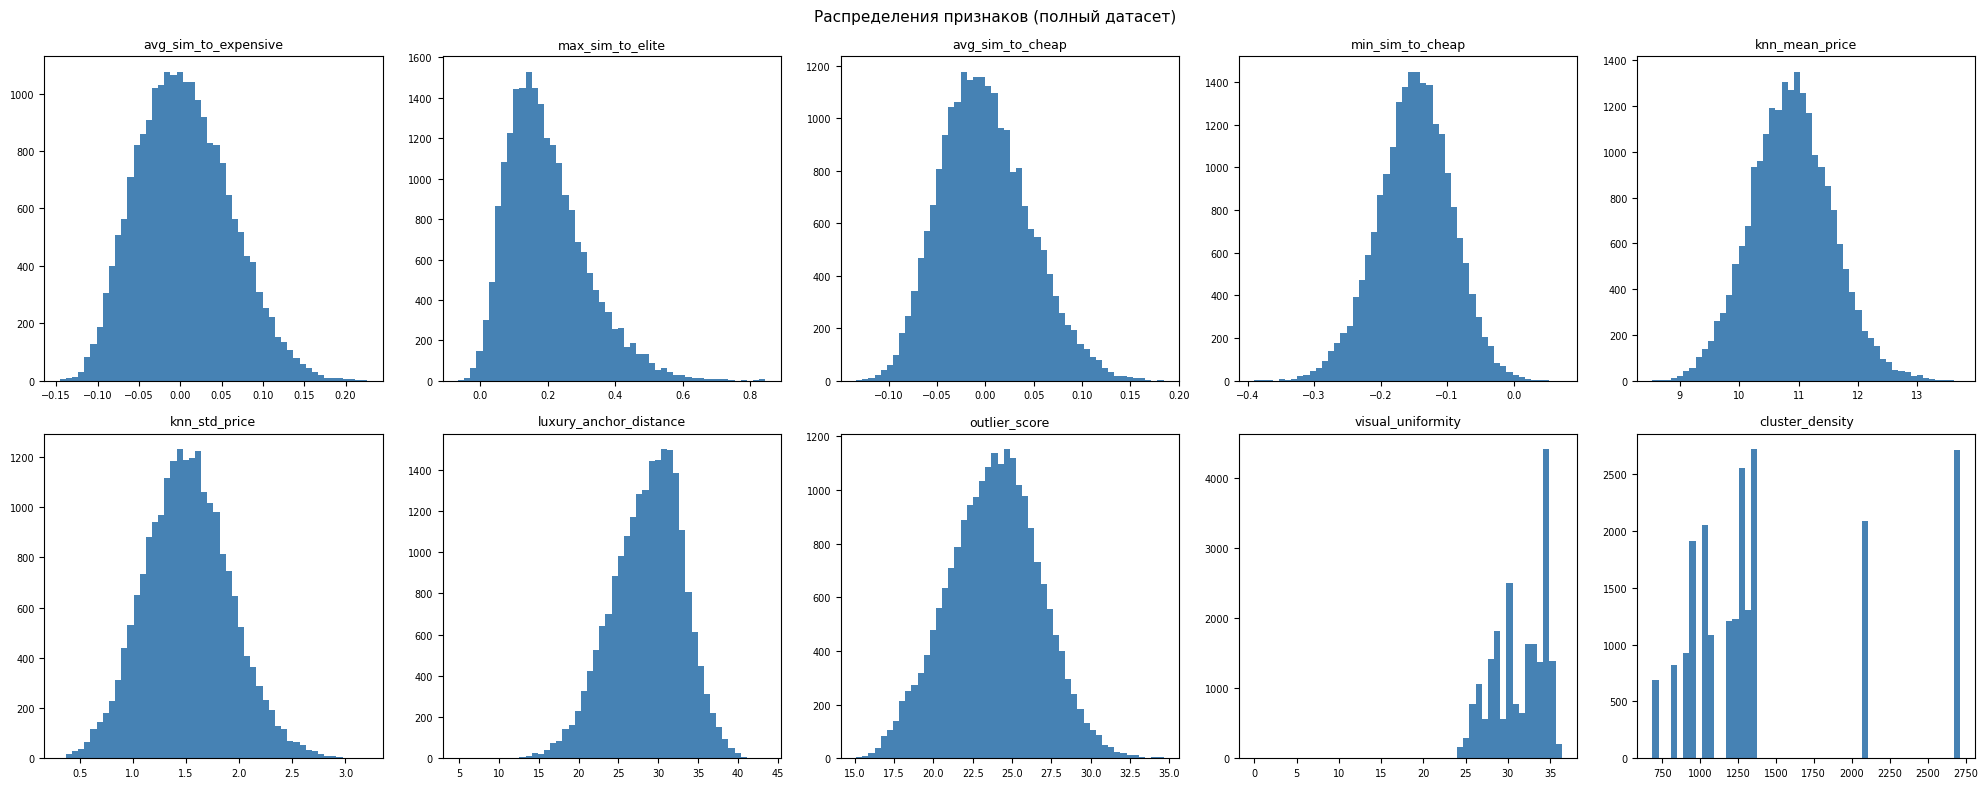

In [62]:
# Проверка 1: размерности
print('=== ПРОВЕРКА 1: РАЗМЕРНОСТИ ===')
print(f'all_outlier_score: {all_outlier_score.shape}')
print(f'all_cluster_density: {all_cluster_density.shape}')
print(f'all_visual_uniformity: {all_visual_uniformity.shape}')
print(f'all_rolling_sim: {all_rolling_sim.shape}')
print(f'df_visual_clean: {df_visual_clean.shape}')
print(f'df_phillips_clean: {df_phillips_clean.shape}')

# Проверка 2: временной порядок
print('\n=== ПРОВЕРКА 2: ВРЕМЕННОЙ ПОРЯДОК ===')
df_check = df_phillips_clean.copy()
df_check['_month'] = pd.to_datetime(df_check['auction_date_clean']).dt.to_period('M')
df_check['knn_mean_price'] = all_rolling_sim['knn_mean_price'].values

check_months = sorted(df_check['_month'].unique())[10:15]
for month in check_months:
    current = df_check[df_check['_month'] == month]
    ref = df_check[df_check['_month'] < month]
    print(f'\nМесяц {month}: {len(current)} лотов, референс: {len(ref)} лотов')
    print(f'  Макс дата в референсе: {ref["auction_date_clean"].max()}')
    print(f'  Мин дата в текущем:    {current["auction_date_clean"].min()}')
    print(f'  Порядок соблюдён:      {ref["auction_date_clean"].max() < current["auction_date_clean"].min()}')

# Проверка 3: NaN паттерн
print('\n=== ПРОВЕРКА 3: NaN ПАТТЕРН ===')
nan_mask = all_rolling_sim['knn_mean_price'].isna()
df_check['_month_str'] = df_check['_month'].astype(str)
nan_months = df_check.loc[nan_mask.values, '_month_str'].value_counts().sort_index()
print(f'Месяцы с NaN:\n{nan_months}')
print(f'Всего NaN: {nan_mask.sum()}')
print(f'Последний месяц с NaN: {nan_months.index.max()}')
print(f'Первый месяц без NaN: {sorted(df_check.loc[~nan_mask.values, "_month_str"].unique())[0]}')

# Проверка 4: содержательная проверка
print('\n=== ПРОВЕРКА 4: ДОРОГИЕ И ДЕШЁВЫЕ ЛОТЫ ===')
df_check2 = df_phillips_clean.copy()
for col in all_rolling_sim.columns:
    df_check2[col] = all_rolling_sim[col].values
df_check2['outlier_score'] = all_outlier_score
df_check2['cluster_density'] = all_cluster_density
df_check2['visual_uniformity'] = all_visual_uniformity
df_check2['labels'] = all_labels_full

top5 = df_check2.nlargest(5, 'price_usd_2026')[
    ['artist', 'price_usd_2026', 'avg_sim_to_expensive', 'max_sim_to_elite',
     'luxury_anchor_distance', 'knn_mean_price']
]
print('Топ-5 дорогих:')
print(top5.to_string())

bottom5 = df_check2.nsmallest(5, 'price_usd_2026')[
    ['artist', 'price_usd_2026', 'avg_sim_to_expensive', 'max_sim_to_elite',
     'luxury_anchor_distance', 'knn_mean_price']
]
print('\nТоп-5 дешёвых:')
print(bottom5.to_string())

# Проверка 5: корректность склейки
print('\n=== ПРОВЕРКА 5: КОРРЕКТНОСТЬ СКЛЕЙКИ ===')
check_indices = [0, 100, 500, 1000, 5000, 15000, 20000]
for idx in check_indices:
    aspect_df = df_all_features.iloc[idx]['aspect_ratio']
    aspect_src = df_visual_clean.iloc[idx]['aspect_ratio']
    label_df = df_all_features.iloc[idx]['labels']
    label_src = all_labels_full[idx]
    knn_df = df_all_features.iloc[idx]['knn_mean_price']
    knn_src = all_rolling_sim.iloc[idx]['knn_mean_price']
    artist_df = df_all_features.iloc[idx]['artist']
    artist_src = df_phillips_clean.iloc[idx]['artist']

    all_match = (np.isclose(aspect_df, aspect_src, equal_nan=True) and
                 label_df == label_src and
                 np.isclose(knn_df, knn_src, equal_nan=True) and
                 artist_df == artist_src)
    print(f'idx={idx}: artist={artist_df}, all_match={all_match}')

# Проверка 6: распределения
print('\n=== ПРОВЕРКА 6: РАСПРЕДЕЛЕНИЯ ===')
feature_cols = [
    'avg_sim_to_expensive', 'max_sim_to_elite', 'avg_sim_to_cheap',
    'min_sim_to_cheap', 'knn_mean_price', 'knn_std_price',
    'luxury_anchor_distance', 'outlier_score', 'visual_uniformity', 'cluster_density'
]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    data = df_check2[col].dropna()
    axes[i].hist(data, bins=50, color='steelblue', edgecolor='none')
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

plt.suptitle('Распределения признаков (полный датасет)', fontsize=11)
plt.tight_layout()
plt.show()

In [61]:
# собираем общий датафрейм с признаками
df_all_features = pd.concat([
    df_phillips_clean,
    df_visual_clean.drop(columns=['local_image_path']),
    pd.DataFrame({
        'labels': all_labels_full,
        'distances_to_center': all_distances_full,
        'cluster_density': all_cluster_density,
        'outlier_score': all_outlier_score,
        'visual_uniformity': all_visual_uniformity
    }),
    all_rolling_sim.reset_index(drop=True)
], axis=1)

# добавляем split
df_all_features['split'] = 'train'
df_all_features.loc[val_mask_clean, 'split'] = 'val'
df_all_features.loc[test_mask_clean, 'split'] = 'test'

# разбиваем
df_train_features = df_all_features[train_mask_clean].reset_index(drop=True)
df_val_features = df_all_features[val_mask_clean].reset_index(drop=True)
df_test_features = df_all_features[test_mask_clean].reset_index(drop=True)

print(f'Train: {df_train_features.shape}')
print(f'Val:   {df_val_features.shape}')
print(f'Test:  {df_test_features.shape}')
print(f'\nNaN в признаках (train):')
feature_cols = ['labels', 'distances_to_center', 'cluster_density', 'outlier_score',
                'visual_uniformity', 'avg_sim_to_expensive', 'knn_mean_price', 'luxury_anchor_distance']
print(df_train_features[feature_cols].isnull().sum())

Train: (10704, 51)
Val:   (4870, 51)
Test:  (5734, 51)

NaN в признаках (train):
labels                     0
distances_to_center        0
cluster_density            0
outlier_score              0
visual_uniformity         95
avg_sim_to_expensive      95
knn_mean_price            95
luxury_anchor_distance    96
dtype: int64


In [63]:
df_train_features.to_csv('/content/drive/MyDrive/phillips_train_features.csv', index=False)
df_val_features.to_csv('/content/drive/MyDrive/phillips_val_features.csv', index=False)
df_test_features.to_csv('/content/drive/MyDrive/phillips_test_features.csv', index=False)

# также сохраняем полный датасет
df_all_features.to_csv('/content/drive/MyDrive/phillips_all_features.csv', index=False)

print(f'Сохранено:')
print(f'  phillips_train_features.csv — {df_train_features.shape}')
print(f'  phillips_val_features.csv   — {df_val_features.shape}')
print(f'  phillips_test_features.csv  — {df_test_features.shape}')
print(f'  phillips_all_features.csv   — {df_all_features.shape}')

Сохранено:
  phillips_train_features.csv — (10704, 51)
  phillips_val_features.csv   — (4870, 51)
  phillips_test_features.csv  — (5734, 51)
  phillips_all_features.csv   — (21308, 51)
